# Genomic prediction in quinoa — Manuscript Figures

Reproducible notebook for the figures in the quinoa genomic-selection manuscript. Sections are organized by figure number. 

## Figure 1 — Phenotypic Trait Distributions

Histogram density plots showing the distribution of seven agronomic traits measured in Australia (AUS, blue) and Pakistan (PAK, yellow).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
from scipy import stats as scipy_stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
# load trait data
auspak_traits = pd.read_csv('../data/AUSPAK_BLUEs_for_phenotype_plots.csv')

auspak_traits.head()

,location,accession,SampleName,DTF,DTH,PtHt,PcleLng,SdLen,TGW,SdW_z
0,AUS,03-21-072RM,S3H3_batch1,47.30,125.00,123.53,32.24,1.91,3.17,-0.10
1,AUS,38,S47_batch3,53.00,116.00,140.00,47.50,2.22,4.23,0.22
2,AUS,Ames-13218,S11_batch3,60.70,131.00,78.95,46.76,1.79,2.62,-2.12
3,AUS,Ames-13721,S1F6_batch1,44.10,104.00,102.41,30.75,1.97,3.27,0.00
4,AUS,Ames-13722,S1C6_batch1,45.43,101.67,115.41,32.41,2.03,3.60,-0.09


In [5]:

def plot_trait_histograms(df, trait_columns=None, figsize=(16, 12), 
                              trait_order=None, bins=25, alpha=0.7):
    """
    Create histogram density plots for each trait, colored by location.
    
    """
    
    # Auto-detect trait columns if not provided
    if trait_columns is None:
        exclude_cols = ['location', 'accession', 'SampleName']
        trait_columns = [col for col in df.columns if col not in exclude_cols]
    
    # Trait display names and units
    trait_info = {
        'DTF': ('Days to Flowering', 'days'),
        'DTH': ('Days to Harvest', 'days'), 
        'PtHt': ('Plant Height', 'cm'),
        'PcleLng': ('Panicle Length', 'cm'),
        'SdW_z': ('Seed Yield', 'z-scaled by environment'),
        'SdLen': ('Seed Length', 'mm'),
        'TGW': ('Thousand Grain Weight', 'grams')
    }
    
    # Location colors: PAK yellow, AUS blue
    location_colors = {'PAK': '#ffaa11', 'AUS': '#1f77b4'}
    locations = sorted(df['location'].unique())
    
    # Determine trait order
    if trait_order is not None:
        available_traits = set(trait_columns)
        traits = [t for t in trait_order if t in available_traits]
        traits.extend(sorted(available_traits - set(traits)))
    else:
        traits = sorted(trait_columns)
    
    # Create 4x2 subplot layout
    fig, axes = plt.subplots(4, 2, figsize=figsize, sharey=False)
    axes = axes.flatten()
    
    # Plot each trait
    for i, trait in enumerate(traits):
        ax = axes[i]
        trait_data = df[['location', trait]].dropna()
        
        if not trait_data.empty and trait_data[trait].notna().any():
            # Calculate plotting range with 5% padding
            data_min, data_max = trait_data[trait].min(), trait_data[trait].max()
            data_range = data_max - data_min
            plot_min = data_min - data_range * 0.05
            plot_max = data_max + data_range * 0.05
            
            # Plot histogram and KDE for each location
            for location in locations:
                location_data = trait_data[trait_data['location'] == location][trait]
                
                if len(location_data) > 0:
                    color = location_colors[location]
                    
                    # Histogram
                    ax.hist(location_data, bins=bins, alpha=alpha, color=color,
                           label=location, density=True, edgecolor='black', linewidth=0.5)
                    
                    # KDE curve
                    if len(location_data) > 1:
                        try:
                            kde = scipy_stats.gaussian_kde(location_data)
                            x_range = np.linspace(plot_min, plot_max, 100)
                            ax.plot(x_range, kde(x_range), color=color, 
                                   linewidth=2, linestyle='-')
                        except:
                            pass  # Skip if KDE fails
                    
                    # Mean line
                    ax.axvline(location_data.mean(), color=color, 
                              linestyle='--', linewidth=2, alpha=0.8)
            
            # Get trait name and units
            trait_name, units = trait_info.get(trait, (trait, 'Value'))
            
            # Format subplot
            ax.set_title(trait_name, fontsize=14, fontweight='bold', pad=10)
            ax.set_xlabel(units, fontsize=12)
            ax.set_ylabel('')
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.grid(True, alpha=0.3)
            
            if data_range > 0:
                ax.set_xlim(plot_min, plot_max)
        
        else:
            # No data available
            trait_name = trait_info.get(trait, (trait, 'Value'))[0]
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   fontsize=18, color='gray', transform=ax.transAxes)
            ax.set_title(trait_name, fontsize=14, fontweight='bold', pad=10)
            ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Hide unused subplots except position 7 (for legend)
    for j in range(len(traits), len(axes)):
        if j != 7:
            axes[j].set_visible(False)
    
    # Add legend to 8th subplot position
    if len(axes) > 7:
        legend_ax = axes[7]
        legend_ax.set_visible(True)
        legend_ax.axis('off')
        
        legend_elements = [
            Patch(facecolor=location_colors['AUS'], alpha=alpha, 
                  edgecolor='black', linewidth=0.5, label='AUS'),
            Patch(facecolor=location_colors['PAK'], alpha=alpha, 
                  edgecolor='black', linewidth=0.5, label='PAK'),
            Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
                   label='Mean values'),
            Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
                   label='Density curves')
        ]
        
        legend_ax.legend(handles=legend_elements, loc='center', fontsize=14,
                        frameon=True, fancybox=True, shadow=True,
                        title='Legend', title_fontsize=16)
    
    plt.tight_layout()
    
    # Add y-axis label for entire figure
    fig.text(0.01, 0.5, 'Density', ha='center', va='center',
             fontsize=14, fontweight='bold', rotation=90)
    
    return fig



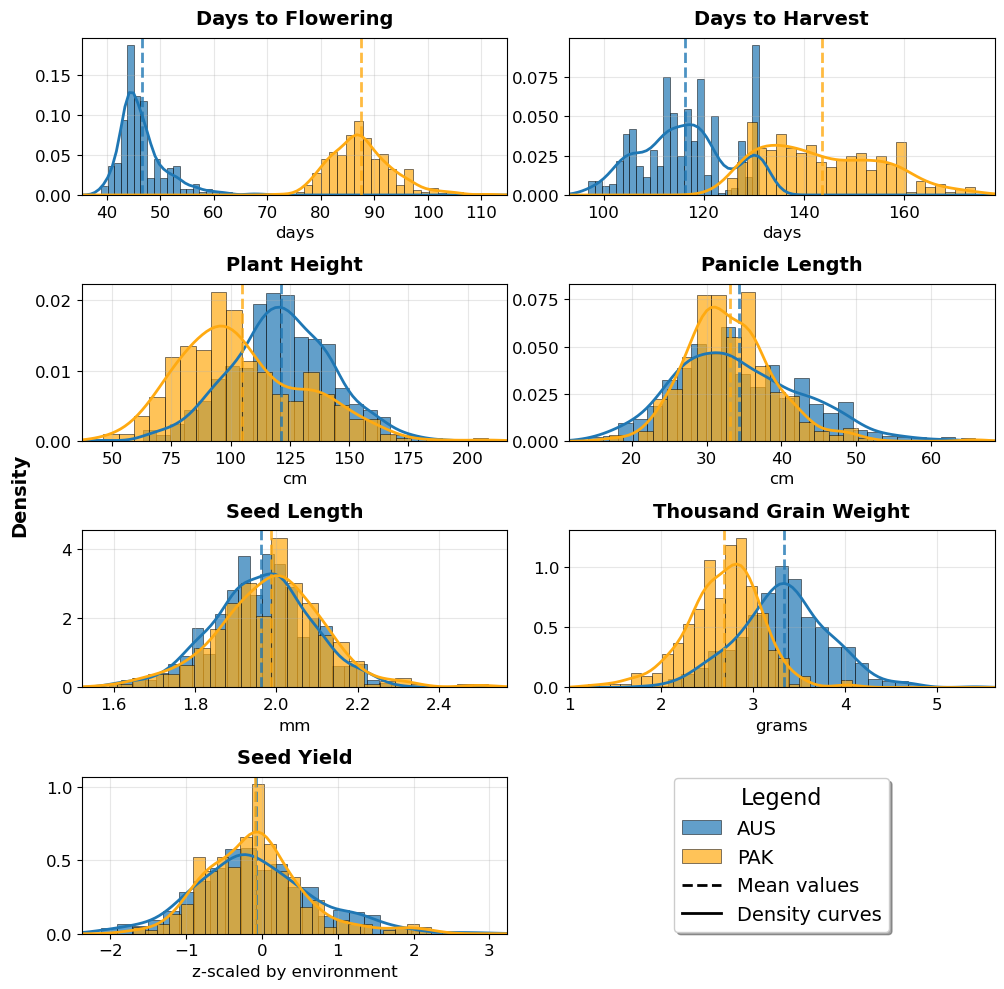

In [6]:
trait_columns = ['PtHt', 'PcleLng', 'TGW', 'SdLen', 'DTF', 'DTH', 'SdW_z']
trait_order = ['DTF', 'DTH', 'PtHt', 'PcleLng', 'SdLen', 'TGW', 'SdW_z']

fig = plot_trait_histograms(auspak_traits, 
                                trait_columns=trait_columns,
                                trait_order=trait_order,
                                figsize=(10, 10),
                                bins=25,
                                alpha=0.7)

fig.savefig('Figure1.png', 
            dpi=300, bbox_inches='tight')

plt.show()

## Figure 2 — Integrated Trait Correlation Matrix

Integrated correlation matrix showing within-location trait relationships, generalized heritabilities, and cross-location correlations for seven agronomic traits evaluated in Australia and Pakistan.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.patches as patches

In [8]:
# load trait data
auspak_traits = pd.read_csv('../data/AUSPAK_BLUEs_for_phenotype_plots.csv')

auspak_traits.head()

,location,accession,SampleName,DTF,DTH,PtHt,PcleLng,SdLen,TGW,SdW_z
0,AUS,03-21-072RM,S3H3_batch1,47.30,125.00,123.53,32.24,1.91,3.17,-0.10
1,AUS,38,S47_batch3,53.00,116.00,140.00,47.50,2.22,4.23,0.22
2,AUS,Ames-13218,S11_batch3,60.70,131.00,78.95,46.76,1.79,2.62,-2.12
3,AUS,Ames-13721,S1F6_batch1,44.10,104.00,102.41,30.75,1.97,3.27,0.00
4,AUS,Ames-13722,S1C6_batch1,45.43,101.67,115.41,32.41,2.03,3.60,-0.09


In [9]:

def plot_triangular_trait_correlations(df, trait_columns=None, location_column='location', 
                                     sample_column='SampleName', figsize=(20, 12),
                                     trait_order=None, significance_level=0.05):
    """
    Create triangular correlation plot with Australia and Pakistan correlations as lower triangles
    Australia is mirrored/flipped so they meet back-to-back with cross-location in the middle
    Trait labels are positioned next to the closest filled box in each triangle
    Diagonal shows heritability values as black text on white background
    Cross-location column uses correlation color scale with AUS/PAK colored borders
    """
    
    # Auto-detect trait columns if not provided
    if trait_columns is None:
        exclude_cols = [location_column, 'accession', sample_column]
        trait_columns = [col for col in df.columns if col not in exclude_cols]
    
    # Define trait name mapping for full names
    trait_name_mapping = {
        'DTF': 'Days to Flowering',
        'DTH': 'Days to Harvest', 
        'PtHt': 'Plant Height',
        'PcleLng': 'Panicle Length',
        'SdW_z': 'Seed Yield',
        'SdLen': 'Seed Length',
        'TGW': 'Thousand Grain Weight'
    }
    
    # Define heritability values for each location (were estimated previously)
    heritability_values = {
        'AUS': {
            'DTF': 0.47,
            'DTH': 0.66,
            'PtHt': 0.67,
            'PcleLng': 0.45,
            'SdLen': 0.74,
            'TGW': 0.56,
            'SdW_z': 0.34
        },
        'PAK': {
            'DTF': 0.57,
            'DTH': 0.77,
            'PtHt': 0.76,
            'PcleLng': 0.43,
            'SdLen': 0.46,
            'TGW': 0.55,
            'SdW_z': 0.33
        }
    }
    
    # Use specified trait order if provided
    if trait_order is not None:
        available_traits = set(trait_columns)
        traits = [trait for trait in trait_order if trait in available_traits]
        remaining_traits = sorted(available_traits - set(traits))
        traits.extend(remaining_traits)
    else:
        traits = sorted(trait_columns)
    
    n_traits = len(traits)
    trait_display_names = [trait_name_mapping.get(trait, trait) for trait in traits]
    
    
    # Get data for each location
    aus_data = df[df[location_column] == 'AUS']
    pak_data = df[df[location_column] == 'PAK']

    # double check that there are no duplicate sample names within each location - since we are using BLUEs there should only be one entry per sample per location
    assert aus_data[sample_column].is_unique, "AUS has duplicate SampleNames"
    assert pak_data[sample_column].is_unique, "PAK has duplicate SampleNames"
    
    # Calculate correlation matrices
    aus_corr = aus_data[traits].corr()
    pak_corr = pak_data[traits].corr()
    
    # Calculate cross-environment correlations
    cross_corr = []
    cross_pvals = []
    
    # Merge data on sample names to get paired observations
    merged_data = pd.merge(aus_data[[sample_column] + traits], 
                          pak_data[[sample_column] + traits], 
                          on=sample_column, suffixes=('_aus', '_pak'))
    
    for trait in traits:
        trait_aus = f"{trait}_aus"
        trait_pak = f"{trait}_pak"
        
        # Remove NaN values
        valid_data = merged_data[[trait_aus, trait_pak]].dropna()
        
        if len(valid_data) >= 3:
            corr_val, p_val = stats.pearsonr(valid_data[trait_aus], valid_data[trait_pak])
            cross_corr.append(corr_val)
            cross_pvals.append(p_val)
        else:
            cross_corr.append(0)
            cross_pvals.append(1.0)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Define positions for the triangular layout
    cell_size = 1.0
    
    # Layout: Australia (flipped lower triangle) + blank column + Pakistan (lower triangle)
    # Total width: n_traits + 1 + n_traits = 2*n_traits + 1
    combined_width = 2 * n_traits + 1
    
    # Correlation colormap 
    corr_cmap = plt.cm.PRGn
    corr_vmin, corr_vmax = -1, 1
    
    # Define colors for borders
    aus_color = '#1f77b4'  # Blue for Australia #1f77b4'
    pak_color = '#ffa700' # slightly darker yellow for more contrast

    # Plot Australia triangle (lower triangle, but mirrored/flipped)
    for i in range(n_traits):
        for j in range(i + 1):  # Lower triangle indices
            # Position in the left triangle (mirrored: rightmost column of left section)
            # For mirroring: instead of x=j, x=(n_traits-1-j) to flip horizontally
            x = (n_traits - 1) - j
            y = n_traits - 1 - i
            
            if i == j:  # Diagonal - use white background for heritability values
                herit_val = heritability_values['AUS'].get(traits[i], 0.0)
                
                # Create rectangle with white background
                rect = patches.Rectangle((x, y), cell_size, cell_size, 
                                       linewidth=3, edgecolor=aus_color,
                                       facecolor='white')
                ax.add_patch(rect)
                
                # Add text annotation for heritability
                ax.text(x + 0.5, y + 0.5, f'{herit_val:.2f}', 
                       ha='center', va='center', fontsize=13, fontweight='bold',
                       color='black')
            else:  # Off-diagonal - use correlation values
                corr_val = aus_corr.iloc[i, j]
                
                # Create rectangle with correlation color scale
                rect = patches.Rectangle((x, y), cell_size, cell_size, 
                                       linewidth=1, edgecolor='white',
                                       facecolor=corr_cmap((corr_val - corr_vmin) / (corr_vmax - corr_vmin)))
                ax.add_patch(rect)
                
                # Check significance for Australia
                aus_pval = calculate_pvalue(aus_data, traits[i], traits[j])
                text = f'{corr_val:.2f}' if aus_pval < significance_level else 'ns'
                ax.text(x + 0.5, y + 0.5, text, 
                       ha='center', va='center', fontsize=13, fontweight='bold')
    
    # Plot Pakistan triangle (normal lower triangle)
    for i in range(n_traits):
        for j in range(i + 1):  # Lower triangle
            # Position in the right triangle (shifted by n_traits + 1 for blank column)
            x = j + n_traits + 1
            y = n_traits - 1 - i
            
            if i == j:  # Diagonal - use white background for heritability values
                herit_val = heritability_values['PAK'].get(traits[i], 0.0)
                
                # Create rectangle with white background and Pakistan colored edge
                rect = patches.Rectangle((x, y), cell_size, cell_size, 
                                       linewidth=3, edgecolor=pak_color,
                                       facecolor='white')
                ax.add_patch(rect)
                
                # Add text annotation for heritability
                ax.text(x + 0.5, y + 0.5, f'{herit_val:.2f}', 
                       ha='center', va='center', fontsize=13, fontweight='bold',
                       color='black')
                
            else:  # Off-diagonal - use correlation values
                corr_val = pak_corr.iloc[i, j]
                
                # Create rectangle with correlation color scale
                rect = patches.Rectangle((x, y), cell_size, cell_size, 
                                       linewidth=1, edgecolor='white',
                                       facecolor=corr_cmap((corr_val - corr_vmin) / (corr_vmax - corr_vmin)))
                ax.add_patch(rect)
                
                # Check significance for Pakistan
                pak_pval = calculate_pvalue(pak_data, traits[i], traits[j])
                text = f'{corr_val:.2f}' if pak_pval < significance_level else 'ns'
                ax.text(x + 0.5, y + 0.5, text, 
                       ha='center', va='center', fontsize=13, fontweight='bold')

    # Plot cross-location correlations (middle column)
    for i in range(n_traits):
        corr_val = cross_corr[i]
        p_val = cross_pvals[i]
        
        # Position in the middle column
        x = n_traits 
        y = n_traits - 1 - i

        # Create rectangle for cross-location correlation using correlation color scale
        rect = patches.Rectangle((x, y), cell_size, cell_size, 
                               linewidth=1, edgecolor='white',
                               facecolor=corr_cmap((corr_val - corr_vmin) / (corr_vmax - corr_vmin)))
        ax.add_patch(rect)
        
        # Add colored border lines
        # Left border (AUS color - blue)
        left_border = patches.Rectangle((x - 0.05, y), 0.15, cell_size, # 0.15 is thicker line, and added 0.05 to move bar slightly over
                                      linewidth=0, 
                                      facecolor=aus_color, alpha=0.9)
        ax.add_patch(left_border)
        
        # Right border (PAK color - orange/yellow)
        right_border = patches.Rectangle((x + cell_size - 0.10, y), 0.15, cell_size, # 0.15 is thicker line
                                       linewidth=0, 
                                       facecolor=pak_color, alpha=0.9)
        ax.add_patch(right_border)
        
        # Add text annotation for cross-correlation
        text = f'{corr_val:.2f}' if p_val < significance_level else 'ns'
        ax.text(x + 0.5, y + 0.5, text, 
               ha='center', va='center', fontsize=13, fontweight='bold')
    
    # Add trait labels positioned next to closest filled boxes
    
    # For Australia triangle (mirrored) - labels go to the left of leftmost filled box in each row
    for i in range(n_traits):
        trait_name = trait_display_names[i]
        y_pos = n_traits - 1 - i + 0.5  # Center of the row
        
        # Find leftmost filled box in this row (Australia triangle)
        # In row i, we have boxes from j=0 to j=i (mirrored positions)
        leftmost_box_x = (n_traits - 1) - i  # This is the leftmost box position in mirrored triangle
        
        # Place label to the left of the leftmost box
        label_x = leftmost_box_x - 0.1
        ax.text(label_x, y_pos, trait_name, 
               ha='right', va='center', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))
    
    # For Pakistan triangle - labels go to the right of rightmost filled box in each row
    for i in range(n_traits):
        trait_name = trait_display_names[i]
        y_pos = n_traits - 1 - i + 0.5  # Center of the row
        
        # Find rightmost filled box in this row (Pakistan triangle)
        # In row i, we have boxes from j=0 to j=i
        rightmost_box_x = i + n_traits + 1  # This is the rightmost box position in Pakistan triangle
        
        # Place label to the right of the rightmost box
        label_x = rightmost_box_x + 1 + 0.1
        ax.text(label_x, y_pos, trait_name, 
               ha='left', va='center', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))
    
    # X-axis labels for Australia (bottom, mirrored)
    for j, trait_name in enumerate(trait_display_names):
        # For mirrored Australia: reverse the order
        x_pos = (n_traits - 1) - j + 0.5
        ax.text(x_pos, -0.1, trait_name, 
               ha='right', va='top', fontsize=12, fontweight='bold', rotation=45)
    
    # X-axis labels for Pakistan (bottom)
    for j, trait_name in enumerate(trait_display_names):
        x_pos = j + n_traits + 1 + 0.5
        ax.text(x_pos, -0.1, trait_name, 
               ha='right', va='top', fontsize=12, fontweight='bold', rotation=45)
    
    # Set up the plot with some extra padding for labels
    ax.set_xlim(-3, combined_width + 3)
    ax.set_ylim(-2, n_traits + 1)
    ax.set_aspect('equal')
    
    # Move location labels to the top
    ax.text(n_traits//2, n_traits + 0.3, 'AUSTRALIA', ha='center', va='bottom', 
           fontsize=16, fontweight='bold', color=aus_color)
    ax.text(n_traits + 1 + n_traits//2, n_traits + 0.3, 'PAKISTAN', ha='center', va='bottom', 
           fontsize=16, fontweight='bold', color=pak_color)
    ax.text(n_traits + 0.5, n_traits + 0.3, 'CROSS-LOCATION', ha='center', va='bottom', 
           fontsize=14, fontweight='bold', color='black')
    
    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add correlation colorbar
    sm_corr = plt.cm.ScalarMappable(cmap=corr_cmap, norm=plt.Normalize(vmin=corr_vmin, vmax=corr_vmax))
    sm_corr.set_array([])
    cbar_corr = plt.colorbar(sm_corr, ax=ax, shrink=0.6, aspect=20, pad=0.02)
    cbar_corr.set_label('Correlation Coefficient', fontsize=12, fontweight='bold')
    cbar_corr.ax.tick_params(labelsize=13)

    
    plt.tight_layout()
    
    return fig, merged_data, cross_corr


def calculate_pvalue(data, trait1, trait2):
    """Calculate p-value for correlation between two traits"""
    data1 = data[trait1].dropna()
    data2 = data[trait2].dropna()
    common_idx = data1.index.intersection(data2.index)
    
    if len(common_idx) >= 3:
        _, p_val = stats.pearsonr(data1.loc[common_idx], data2.loc[common_idx])
        return p_val
    else:
        return 1.0

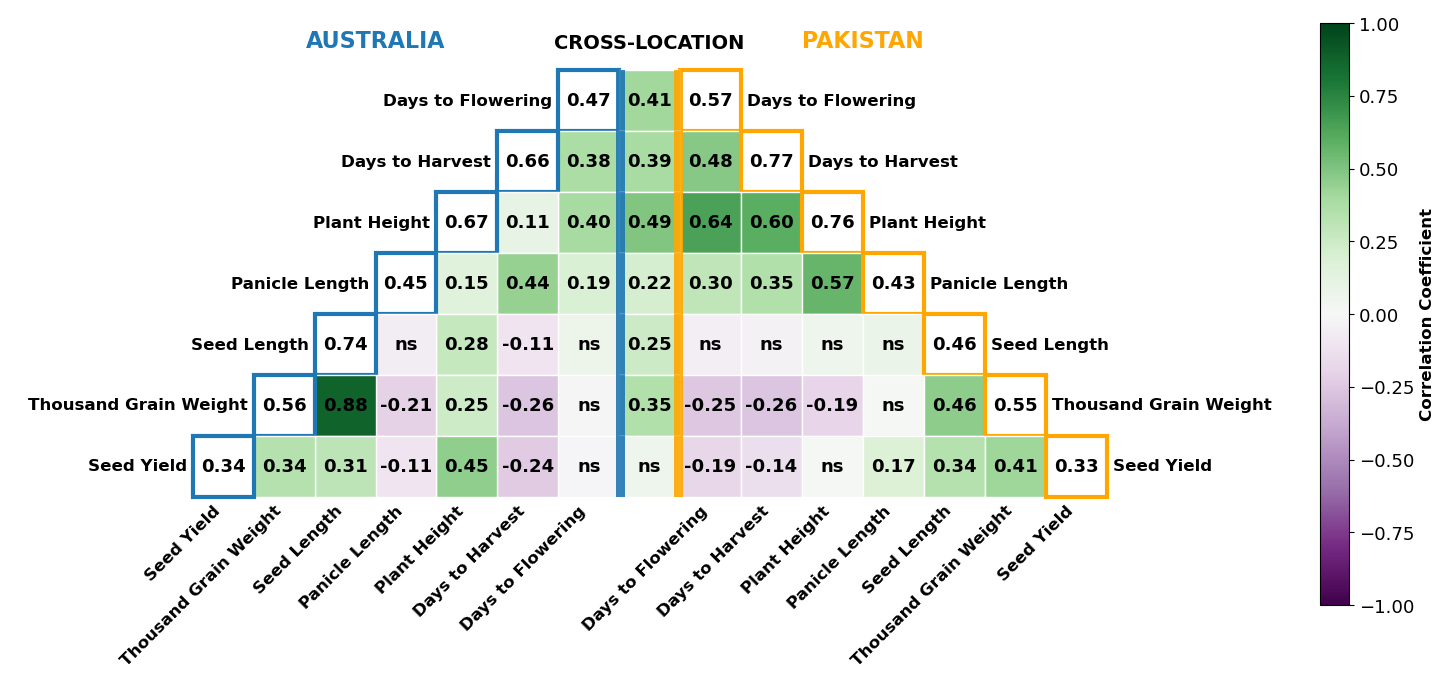

In [10]:
trait_order = ['DTF', 'DTH', 'PtHt', 'PcleLng', 'SdLen', 'TGW', 'SdW_z']
trait_columns = ['PtHt', 'PcleLng', 'TGW', 'SdLen', 'DTF', 'DTH', 'SdW_z']

fig, merged_data, cross_correlations = plot_triangular_trait_correlations(
    auspak_traits, 
    trait_columns=trait_columns,
    location_column='location',
    sample_column='SampleName', 
    trait_order=trait_order,
    figsize=(16, 10),
    significance_level=0.05
)

fig.savefig('Figure2.png', 
            dpi=300, bbox_inches='tight')
plt.show()



In [11]:
cross_correlations

[np.float64(0.4130159215623938),
 np.float64(0.3879314338693574),
 np.float64(0.4939500161240386),
 np.float64(0.21697150117956554),
 np.float64(0.2538626036432954),
 np.float64(0.35212670587369505),
 np.float64(0.058130125795126324)]

## Figure S1 — Within-Location Year-Pair Trait Correlations

Supplementary figure: pairwise correlations between accession means across years within the same location.

  AUS: years = [np.int64(2017), np.int64(2018), np.int64(2019)], n_samples = 551, n_rows = 1147
  PAK: years = [np.int64(2019), np.int64(2020), np.int64(2021)], n_samples = 300, n_rows = 752

── Year-pair correlations ──
Loc   Trait    Pair              r        p    n
------------------------------------------------
AUS   DTF      2017-2018       nan   1.0000    0
AUS   DTF      2017-2019       nan   1.0000    0
AUS   DTF      2018-2019     0.381   0.0000  213
AUS   DTH      2017-2018       nan   1.0000    0
AUS   DTH      2017-2019       nan   1.0000    0
AUS   DTH      2018-2019     0.812   0.0000  211
AUS   PcleLng  2017-2018       nan   1.0000    0
AUS   PcleLng  2017-2019       nan   1.0000    0
AUS   PcleLng  2018-2019     0.243   0.0003  213
AUS   PtHt     2017-2018     0.524   0.0000  368
AUS   PtHt     2017-2019     0.279   0.0001  188
AUS   PtHt     2018-2019     0.502   0.0000  213
AUS   SdLen    2017-2018       nan   1.0000    0
AUS   SdLen    2017-2019       nan   1.0000 

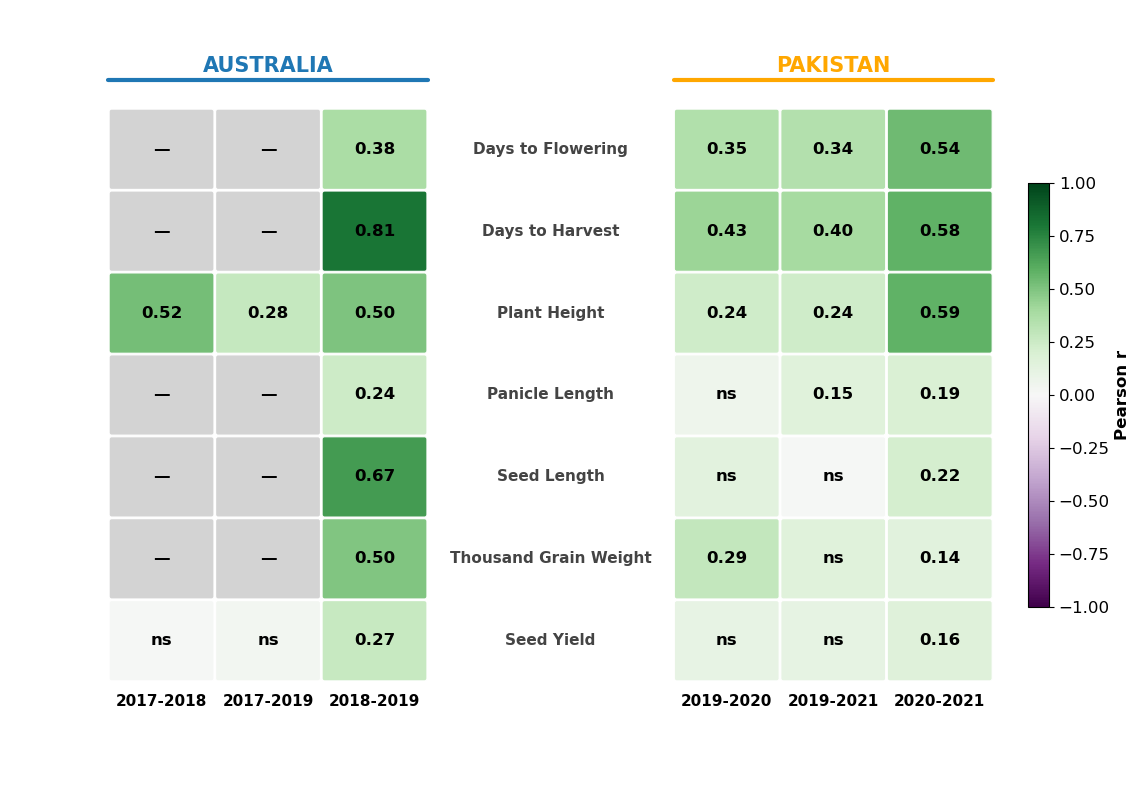

Saved: FigureS1.png


In [14]:
### Heatmap grid: within-location trait correlations across year-pairs
### Rows = traits, Columns = pairwise year combos, side-by-side blocks for AUS & PAK

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import stats
from itertools import combinations


# ── Load & prep data ────────────────────────────────────────────────
auspak_traits = pd.read_csv('../data/AUSPAK_phenotypes_GP_input.csv')

# Sanity check
for loc in ['AUS', 'PAK']:
    subset = auspak_traits[auspak_traits['location'] == loc]
    yrs = sorted(subset['year'].unique())
    n_samples = subset['sample.id'].nunique()
    n_rows = len(subset)
    print(f"  {loc}: years = {yrs}, n_samples = {n_samples}, n_rows = {n_rows}")


# ── Configuration ───────────────────────────────────────────────────
trait_order = ['DTF', 'DTH', 'PtHt', 'PcleLng', 'SdLen', 'TGW', 'SdW_z']
trait_columns = ['PtHt', 'PcleLng', 'TGW', 'SdLen', 'DTF', 'DTH', 'SdW_z']

trait_name_mapping = {
    'DTF': 'Days to Flowering',
    'DTH': 'Days to Harvest',
    'PtHt': 'Plant Height',
    'PcleLng': 'Panicle Length',
    'SdW_z': 'Seed Yield',
    'SdLen': 'Seed Length',
    'TGW': 'Thousand Grain Weight'
}

loc_full_names = {'AUS': 'AUSTRALIA', 'PAK': 'PAKISTAN'}

# Location-specific years
location_years = {
    'AUS': [2017, 2018, 2019],
    'PAK': [2019, 2020, 2021]
}

aus_color = '#1f77b4'
pak_color = '#ffa700'
significance_level = 0.05


# ── Helper: correlation + p-value between two year-subsets for a trait
def year_pair_correlation(df, trait, year_col, year_a, year_b, sample_col='sample.id'):
    """Pearson r between a trait measured in two different years (matched by sample)."""
    da = df[df[year_col] == year_a][[sample_col, trait]].dropna().rename(columns={trait: 'val_a'})
    db = df[df[year_col] == year_b][[sample_col, trait]].dropna().rename(columns={trait: 'val_b'})
    merged = pd.merge(da, db, on=sample_col).dropna()
    if len(merged) >= 3:
        r, p = stats.pearsonr(merged['val_a'], merged['val_b'])
        return r, p, len(merged)
    return np.nan, 1.0, 0


# ── Compute correlations ────────────────────────────────────────────
traits = [t for t in trait_order if t in trait_columns]

locations = ['AUS', 'PAK']
results = {}  # results[(loc, trait, pair_label)] = (r, p, n)

for loc in locations:
    years = location_years[loc]
    loc_data = auspak_traits[auspak_traits['location'] == loc]
    year_pairs = list(combinations(years, 2))

    for trait in traits:
        for ya, yb in year_pairs:
            pair_label = f'{ya}-{yb}'
            r, p, n = year_pair_correlation(loc_data, trait, 'year', ya, yb)
            results[(loc, trait, pair_label)] = (r, p, n)

# Diagnostic
print("\n── Year-pair correlations ──")
print(f"{'Loc':<5} {'Trait':<8} {'Pair':<12} {'r':>6} {'p':>8} {'n':>4}")
print("-" * 48)
for (loc, trait, pair), (r, p, n) in sorted(results.items()):
    print(f"{loc:<5} {trait:<8} {pair:<12} {r:>6.3f} {p:>8.4f} {n:>4}")
print()


# ── Build figure ────────────────────────────────────────────────────
n_traits = len(traits)
aus_pairs = [f'{a}-{b}' for a, b in combinations(location_years['AUS'], 2)]
pak_pairs = [f'{a}-{b}' for a, b in combinations(location_years['PAK'], 2)]
n_pairs = 3  # always C(3,2)=3

cell_w = 1.3
cell_h = 1.0
gap = 3.0          # horizontal gap between AUS and PAK blocks
label_pad = 0.15   # space between labels and cells

# Grid dimensions
block_w = n_pairs * cell_w
total_w = 2 * block_w + gap
total_h = n_traits * cell_h

# Origin of each block (bottom-left)
aus_x0 = 0
pak_x0 = block_w + gap

fig, ax = plt.subplots(figsize=(13, 8))

corr_cmap = plt.cm.PRGn
norm = plt.Normalize(vmin=-1, vmax=1)


def draw_block(ax, x0, loc, pair_labels, border_color):
    """Draw one location's heatmap block."""
    for row_i, trait in enumerate(traits):
        y = total_h - 1 - row_i  # top row = first trait
        for col_j, pair in enumerate(pair_labels):
            x = x0 + col_j * cell_w
            r, p, n = results[(loc, trait, pair)]

            if np.isnan(r):
                fc = 'lightgray'
                txt = '—'
            else:
                fc = corr_cmap(norm(r))
                txt = f'{r:.2f}' if p < significance_level else 'ns'

            rect = patches.FancyBboxPatch(
                (x + 0.04, y + 0.04), cell_w - 0.08, cell_h - 0.08,
                boxstyle="round,pad=0.03",
                linewidth=0.8, edgecolor='white', facecolor=fc)
            ax.add_patch(rect)

            ax.text(x + cell_w / 2, y + cell_h / 2, txt,
                    ha='center', va='center', fontsize=12, fontweight='bold')

    # Column headers (year-pair labels) — moved to BOTTOM of block
    for col_j, pair in enumerate(pair_labels):
        x = x0 + col_j * cell_w + cell_w / 2
        ax.text(x, -0.15, pair, ha='center', va='top',
                fontsize=11, fontweight='bold', rotation=0)

    # Location title
    cx = x0 + block_w / 2
    ax.text(cx, total_h + 0.4, loc_full_names.get(loc, loc.upper()),
        ha='center', va='bottom', fontsize=15, fontweight='bold', color=border_color)

    # Colored underline for title
    ax.plot([x0, x0 + block_w], [total_h + 0.35, total_h + 0.35],
            lw=3, color=border_color, solid_capstyle='round')


# Draw both blocks
draw_block(ax, aus_x0, 'AUS', aus_pairs, aus_color)
draw_block(ax, pak_x0, 'PAK', pak_pairs, pak_color)

# Row labels — only the full trait name in the center between the two blocks (bold, not italic)
for row_i, trait in enumerate(traits):
    y = total_h - 1 - row_i + cell_h / 2
    label = trait_name_mapping.get(trait, trait)

    cx = aus_x0 + block_w + gap / 2
    ax.text(cx, y, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='#444444')

# Axes cosmetics
pad = 1.2
ax.set_xlim(-pad, pak_x0 + block_w + pad)
ax.set_ylim(-1.2, total_h + 1.2)
ax.set_aspect('equal')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Colorbar
sm = plt.cm.ScalarMappable(cmap=corr_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, aspect=20, pad=-0.05)
cbar.set_label('Pearson r', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

fig.savefig('FigureS1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: FigureS1.png")

# Genomic Prediction Results

In [15]:
# ── Setup: imports, constants, and plotting helpers ──────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

TRAIT_ORDER = ['DTF', 'DTH', 'PtHt', 'PcleLng', 'SdLen', 'TGW', 'SdW_z']

TRAIT_LABELS = {
    'DTF':     'Days to\nFlowering',
    'DTH':     'Days to\nHarvest',
    'PtHt':    'Plant\nHeight',
    'PcleLng': 'Panicle\nLength',
    'SdLen':   'Seed\nLength',
    'TGW':     'Thousand Grain\nWeight',
    'SdW_z':   'Seed\nYield',
}

MODEL_ORDER  = ['GBLUP', 'RKHS', 'BayesC', 'LightGBM']
MODEL_LABELS = {'GBLUP': 'GBLUP', 'RKHS': 'RKHS',
                'BayesC': 'BayesC', 'LightGBM': 'LGBM'}
MODEL_MARKERS = {'GBLUP': 'o', 'RKHS': '^', 'BayesC': 's', 'LightGBM': 'D'}
MODEL_HATCHES = {'GBLUP': '',  'RKHS': '///', 'BayesC': 'xxx', 'LightGBM': '...'}

LOCATION_COLORS  = {'PAK': '#ffaa11', 'AUS': '#1f77b4'}
DIRECTION_COLORS = {'PAK→AUS': '#1f77b4', 'AUS→PAK': '#ffaa11'}

METRICS = ['pearson', 'ndcg_at_10']
METRIC_ROW_LABEL = {'pearson': 'PEARSON', 'ndcg_at_10': 'NDCG@10'}
METRIC_YAXIS = {
    'pearson':    'Prediction Accuracy (Pearson r)',
    'ndcg_at_10': 'Selection Ranking (NDCG@10)',
}

SCHEME_TITLES = {
    'CV0':      'Leave-One-Location-Year-Out (CV0)',
    'CV1':      'New Genotypes (CV1)',
    'CV2':      'Sparse Testing (CV2)',
    'CrossLoc': 'Cross-Location',
}


def load_and_restructure(filepath):
    """Load CSV, parse fields, and split by CV scheme."""
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df):,} rows from {os.path.basename(filepath)}")

    for col in ['pearson', 'ndcg_at_10', 'n_test_genotypes',
                'iteration', 'fold', 'seed']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    cl_mask = df['cv_scheme'].str.startswith('CrossLoc', na=False)
    if cl_mask.any():
        parts = df.loc[cl_mask, 'cv_scheme'].str.extract(
            r'CrossLoc_(\w+)->(\w+)')
        df.loc[cl_mask, 'train_location']   = parts[0].values
        df.loc[cl_mask, 'predict_location'] = parts[1].values
        df.loc[cl_mask, 'direction'] = (
            parts[0].values + '→' + parts[1].values
        )
        df.loc[cl_mask, 'cv_scheme'] = 'CrossLoc'

    subsets = {}
    for scheme in ['CV0', 'CV1', 'CV2', 'CrossLoc']:
        sub = df[df['cv_scheme'] == scheme].copy().reset_index(drop=True)
        subsets[scheme] = sub
        print(f"  {scheme:12s}: {len(sub):>6,} rows")
    return subsets


def _prepare_long(df):
    """Melt the two metrics into long format."""
    if df.empty:
        return pd.DataFrame()
    id_vars = [c for c in df.columns if c not in METRICS]
    melted = pd.melt(df, id_vars=id_vars, value_vars=METRICS,
                     var_name='metric', value_name='value')
    return melted.dropna(subset=['value'])


def _draw_boxplot(ax, data_list, positions, colors, hatches=None):
    """Draw styled boxplots on an axes."""
    bp = ax.boxplot(data_list, positions=positions, widths=0.85,
                    patch_artist=True, showfliers=True)
    for i, (box, med) in enumerate(zip(bp['boxes'], bp['medians'])):
        box.set_facecolor(colors[i])
        box.set_edgecolor('black')
        box.set_linewidth(1.0)
        box.set_alpha(0.85)
        if hatches is not None:
            box.set_hatch(hatches[i])
        med.set_color('black')
        med.set_linewidth(1.5)
    for i in range(len(data_list)):
        for el in [bp['whiskers'][2 * i], bp['whiskers'][2 * i + 1],
                   bp['caps'][2 * i],     bp['caps'][2 * i + 1]]:
            el.set_color('black')
            el.set_linewidth(1.0)
        flier = bp['fliers'][i]
        if len(flier.get_data()[0]) > 0:
            flier.set_markerfacecolor(colors[i])
            flier.set_markeredgecolor('black')
            flier.set_markersize(3)


def _draw_dotplot(ax, data_list, positions, colors, markers=None):
    """Draw jittered dot/strip plot on an axes."""
    rng = np.random.default_rng(42)
    for i, (pos, vals, col) in enumerate(zip(positions, data_list, colors)):
        mkr = markers[i] if markers is not None else 'o'
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(pos + jitter, vals, c=col, edgecolors='black',
                   marker=mkr, s=100, alpha=0.90, zorder=3, linewidths=0.8)
        ax.hlines(np.mean(vals), pos - 0.3, pos + 0.3,
                  colors='black', linewidths=1.5, zorder=4)


def plot_results(df, cv_scheme,
                 group_col='location', group_colors=None,
                 plot_type='box', figsize=(26, 16)):
    """Create a metric-rows x trait-columns grid of box or dot plots."""
    melted = _prepare_long(df)
    if melted.empty:
        print(f"  No data for {cv_scheme}")
        return None

    traits  = [t for t in TRAIT_ORDER  if t in melted['trait'].unique()]
    models  = [m for m in MODEL_ORDER  if m in melted['model'].unique()]
    groups  = sorted(melted[group_col].dropna().unique())
    metrics = [m for m in METRICS      if m in melted['metric'].unique()]

    if group_colors is None:
        group_colors = LOCATION_COLORS

    nrows, ncols = len(metrics), len(traits)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey='row')
    plt.rcParams['hatch.linewidth'] = 0.8
    if nrows == 1:
        axes = axes.reshape(1, -1)
    if ncols == 1:
        axes = axes.reshape(-1, 1)

    n_grp     = len(groups)
    model_gap = n_grp + 0.5
    model_ctr = [i * model_gap for i in range(len(models))]

    for mi, metric in enumerate(metrics):
        vals_all = melted[melted['metric'] == metric]['value'].dropna()
        ymin = vals_all.min() - 0.05 if not vals_all.empty else 0
        ymax = vals_all.max() + 0.18 if not vals_all.empty else 1

        for ti, trait in enumerate(traits):
            ax = axes[mi, ti]
            subset = melted[(melted['metric'] == metric) &
                            (melted['trait'] == trait)]

            positions, data_list, colors = [], [], []
            markers_list, hatches_list = [], []

            for midx, model in enumerate(models):
                ctr = model_ctr[midx]
                for gidx, grp in enumerate(groups):
                    pos  = ctr + (gidx - (n_grp - 1) / 2) * 0.8
                    vals = subset[(subset['model'] == model) &
                                  (subset[group_col] == grp)]['value'].values
                    if len(vals) > 0:
                        positions.append(pos)
                        data_list.append(vals)
                        colors.append(group_colors.get(grp, 'gray'))
                        markers_list.append(MODEL_MARKERS.get(model, 'o'))
                        hatches_list.append(MODEL_HATCHES.get(model, ''))

            if data_list:
                if plot_type == 'box':
                    _draw_boxplot(ax, data_list, positions, colors,
                                  hatches_list)
                else:
                    _draw_dotplot(ax, data_list, positions, colors,
                                  markers_list)

                for pos, vals in zip(positions, data_list):
                    ax.text(pos, ymax - 0.02, f'{np.mean(vals):.2f}',
                            ha='center', va='top', fontsize=18,
                            fontweight='medium', rotation=90)

            ax.set_ylim(ymin, ymax)
            ax.set_xticks([])
            ax.grid(True, alpha=0.3, axis='y')
            ax.tick_params(axis='y', labelsize=20)

            if mi == 0:
                ax.set_title(TRAIT_LABELS.get(trait, trait),
                             fontsize=26, fontweight='bold', pad=24)

            if ti == ncols - 1:
                ax2 = ax.twinx()
                ax2.set_ylabel(METRIC_ROW_LABEL[metric], fontsize=24,
                               fontweight='bold', rotation=270, labelpad=30)
                ax2.set_yticks([])

            if ti == 0:
                ax.set_ylabel(METRIC_YAXIS[metric],
                              fontsize=20, fontweight='bold')

    group_handles = [Patch(facecolor=group_colors[g], edgecolor='black',
                           label=g)
                     for g in groups]
    if plot_type == 'dot':
        model_handles = [
            Line2D([0], [0], marker=MODEL_MARKERS.get(m, 'o'),
                   color='gray', markeredgecolor='black',
                   markersize=20, linestyle='None',
                   label=MODEL_LABELS.get(m, m))
            for m in models
        ]
    else:
        model_handles = [
            Patch(facecolor='white', edgecolor='black',
                  hatch=MODEL_HATCHES.get(m, ''),
                  label=MODEL_LABELS.get(m, m))
            for m in models
        ]

    all_handles = group_handles + model_handles
    leg = fig.legend(handles=all_handles, loc='lower center',
                     bbox_to_anchor=(0.5, -0.01),
                     ncol=len(all_handles), fontsize=25,
                     title='Location & Model', title_fontsize=28,
                     frameon=True, fancybox=True, shadow=True,
                     handleheight=2.0, handlelength=2.5)
    leg.get_title().set_fontweight('bold')

    fig.suptitle(SCHEME_TITLES.get(cv_scheme, cv_scheme),
                 fontsize=30, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10, wspace=0.15, hspace=0.15)
    return fig


# ── Load genomic prediction results ──────────────────────────────────
gp_data = load_and_restructure('cv_results_all_models.csv')


Loaded 22,496 rows from cv_results_all_models.csv
  CV0         :    148 rows
  CV1         : 11,100 rows
  CV2         : 11,100 rows
  CrossLoc    :    148 rows


## Figure 3 — New Genotypes (CV1)

Within-location prediction accuracy and selection ranking for unseen genotypes. Boxplots summarize across folds, seeds, and location-years per model × location.

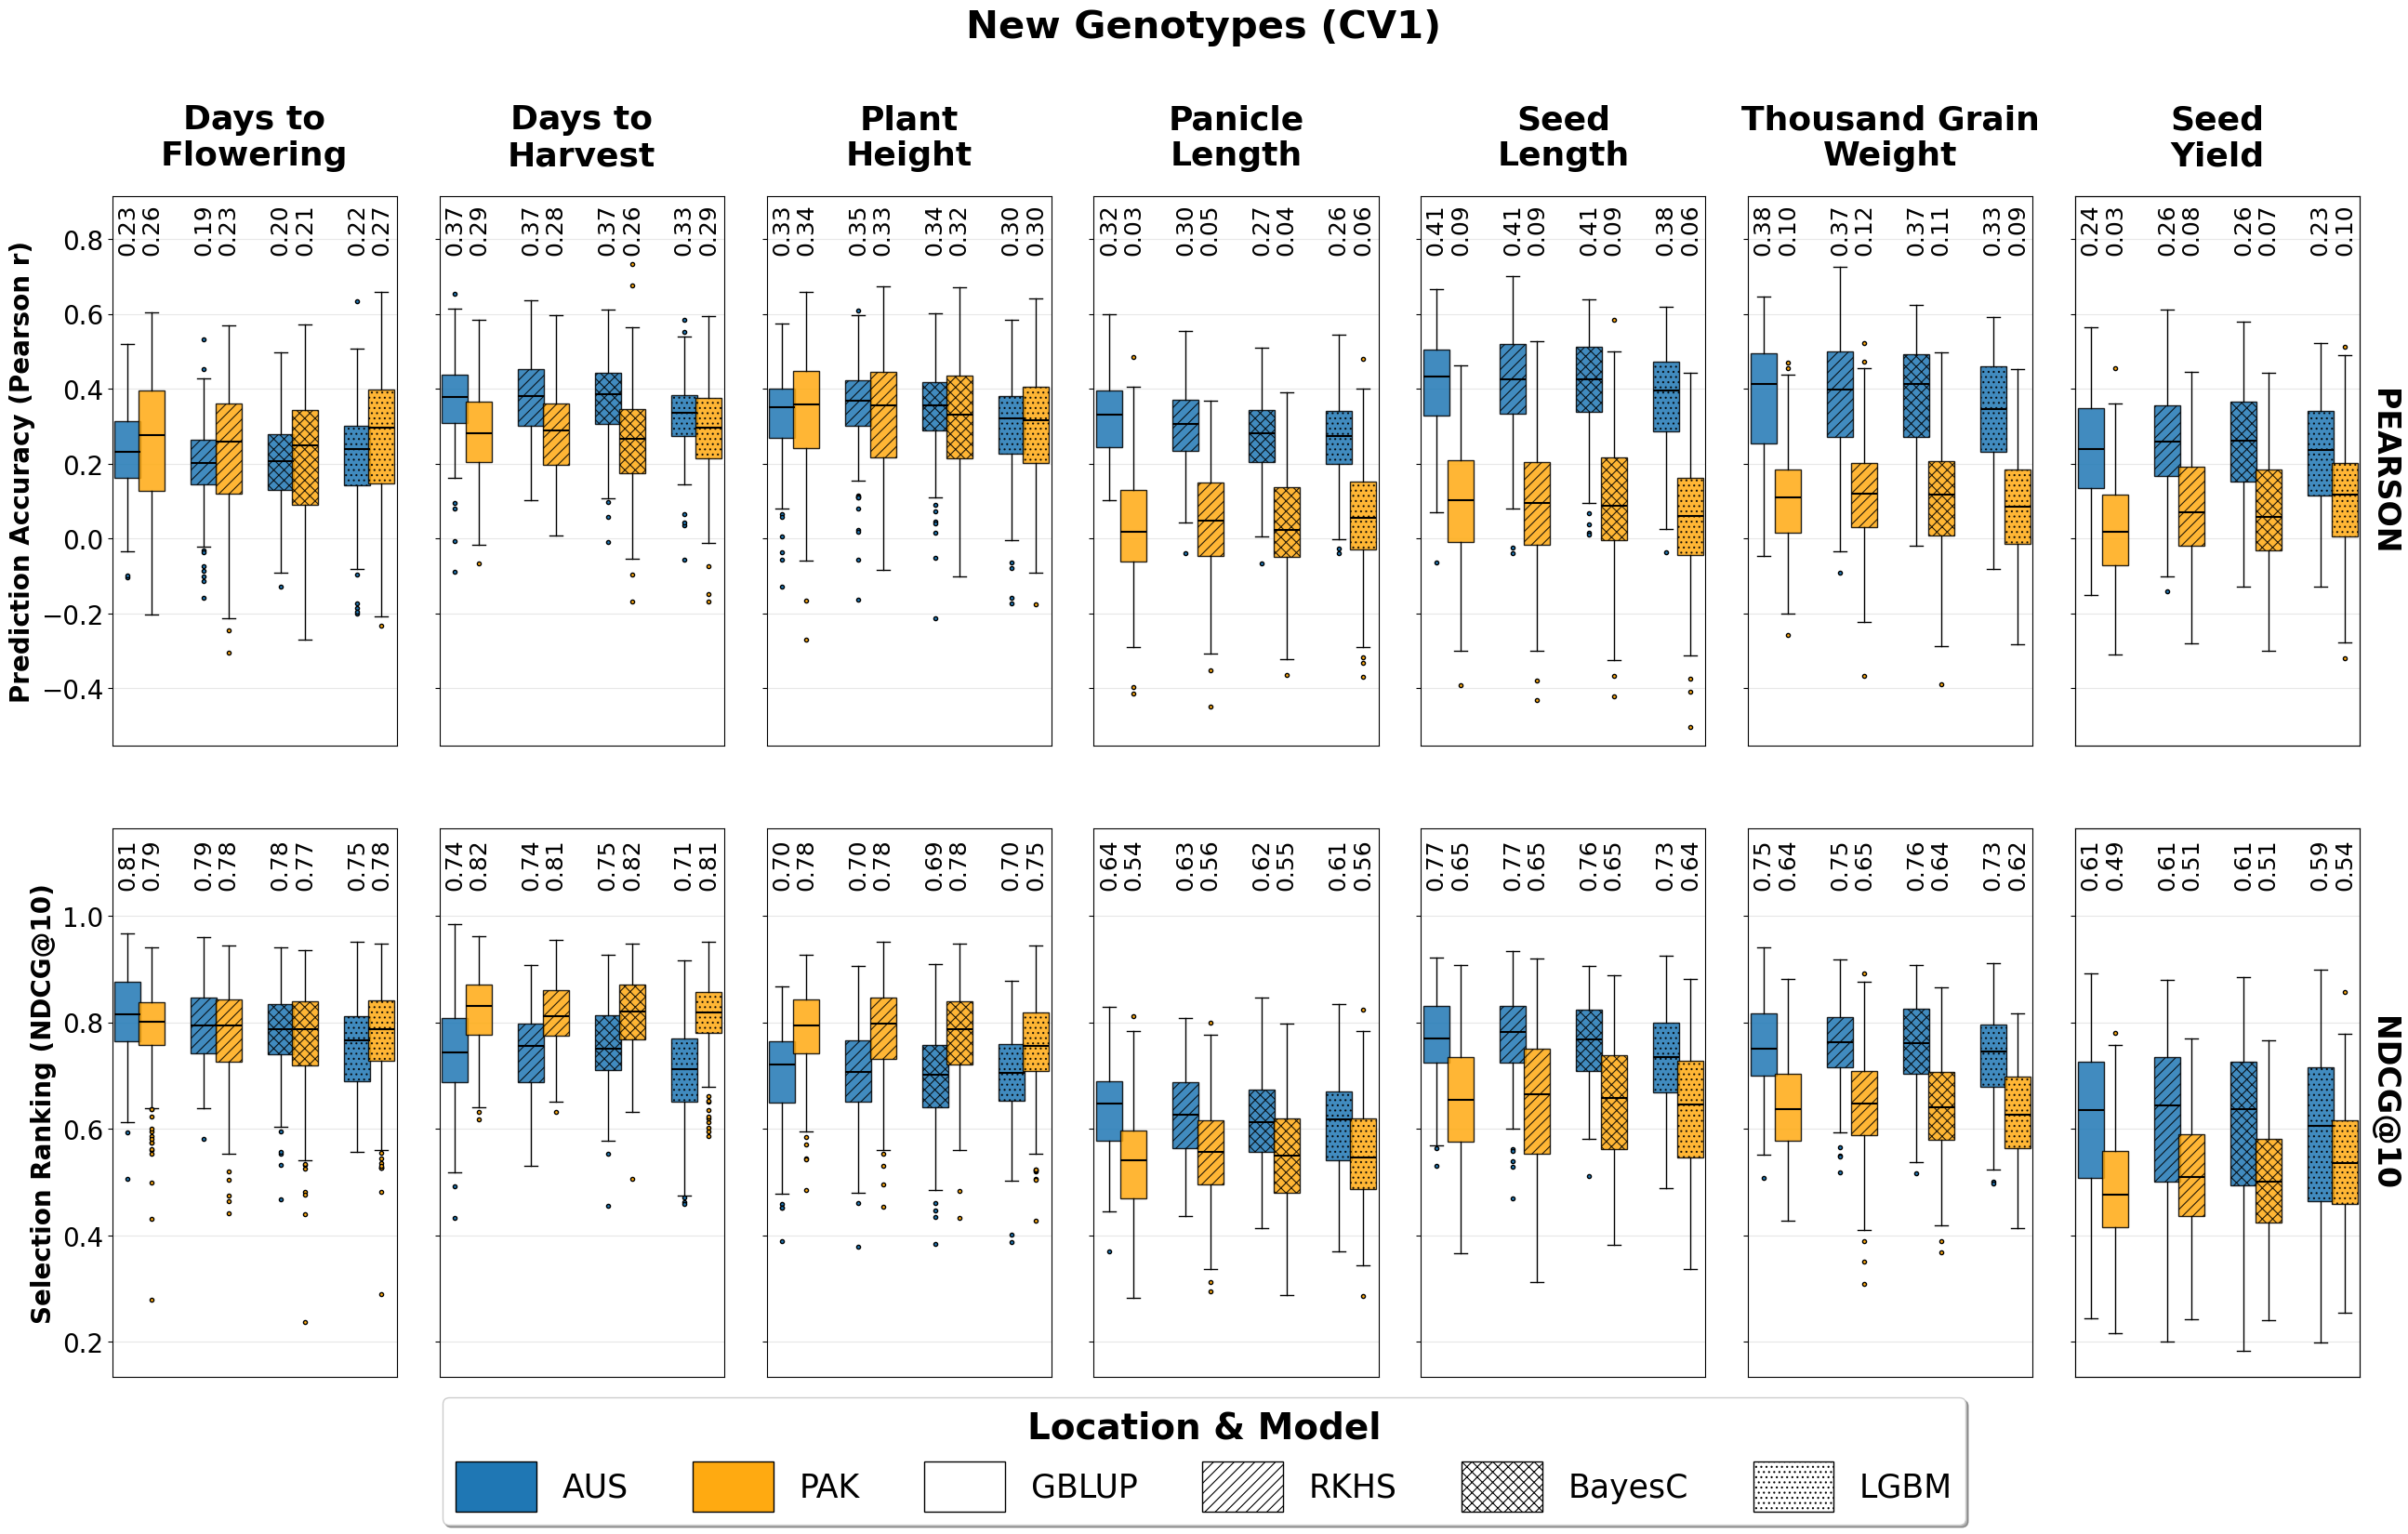

In [17]:
fig_cv1 = plot_results(gp_data['CV1'], 'CV1',
                       plot_type='box',
                       group_col='location',
                       group_colors=LOCATION_COLORS)
if fig_cv1:
    fig_cv1.savefig('Figure3.png',
                    dpi=300, bbox_inches='tight')
plt.show()

## Figure 4 — Sparse Testing (CV2)

Within-location prediction with partial overlap of genotypes across years (sparse testing design). Boxplots summarize across folds and seeds per model × location.

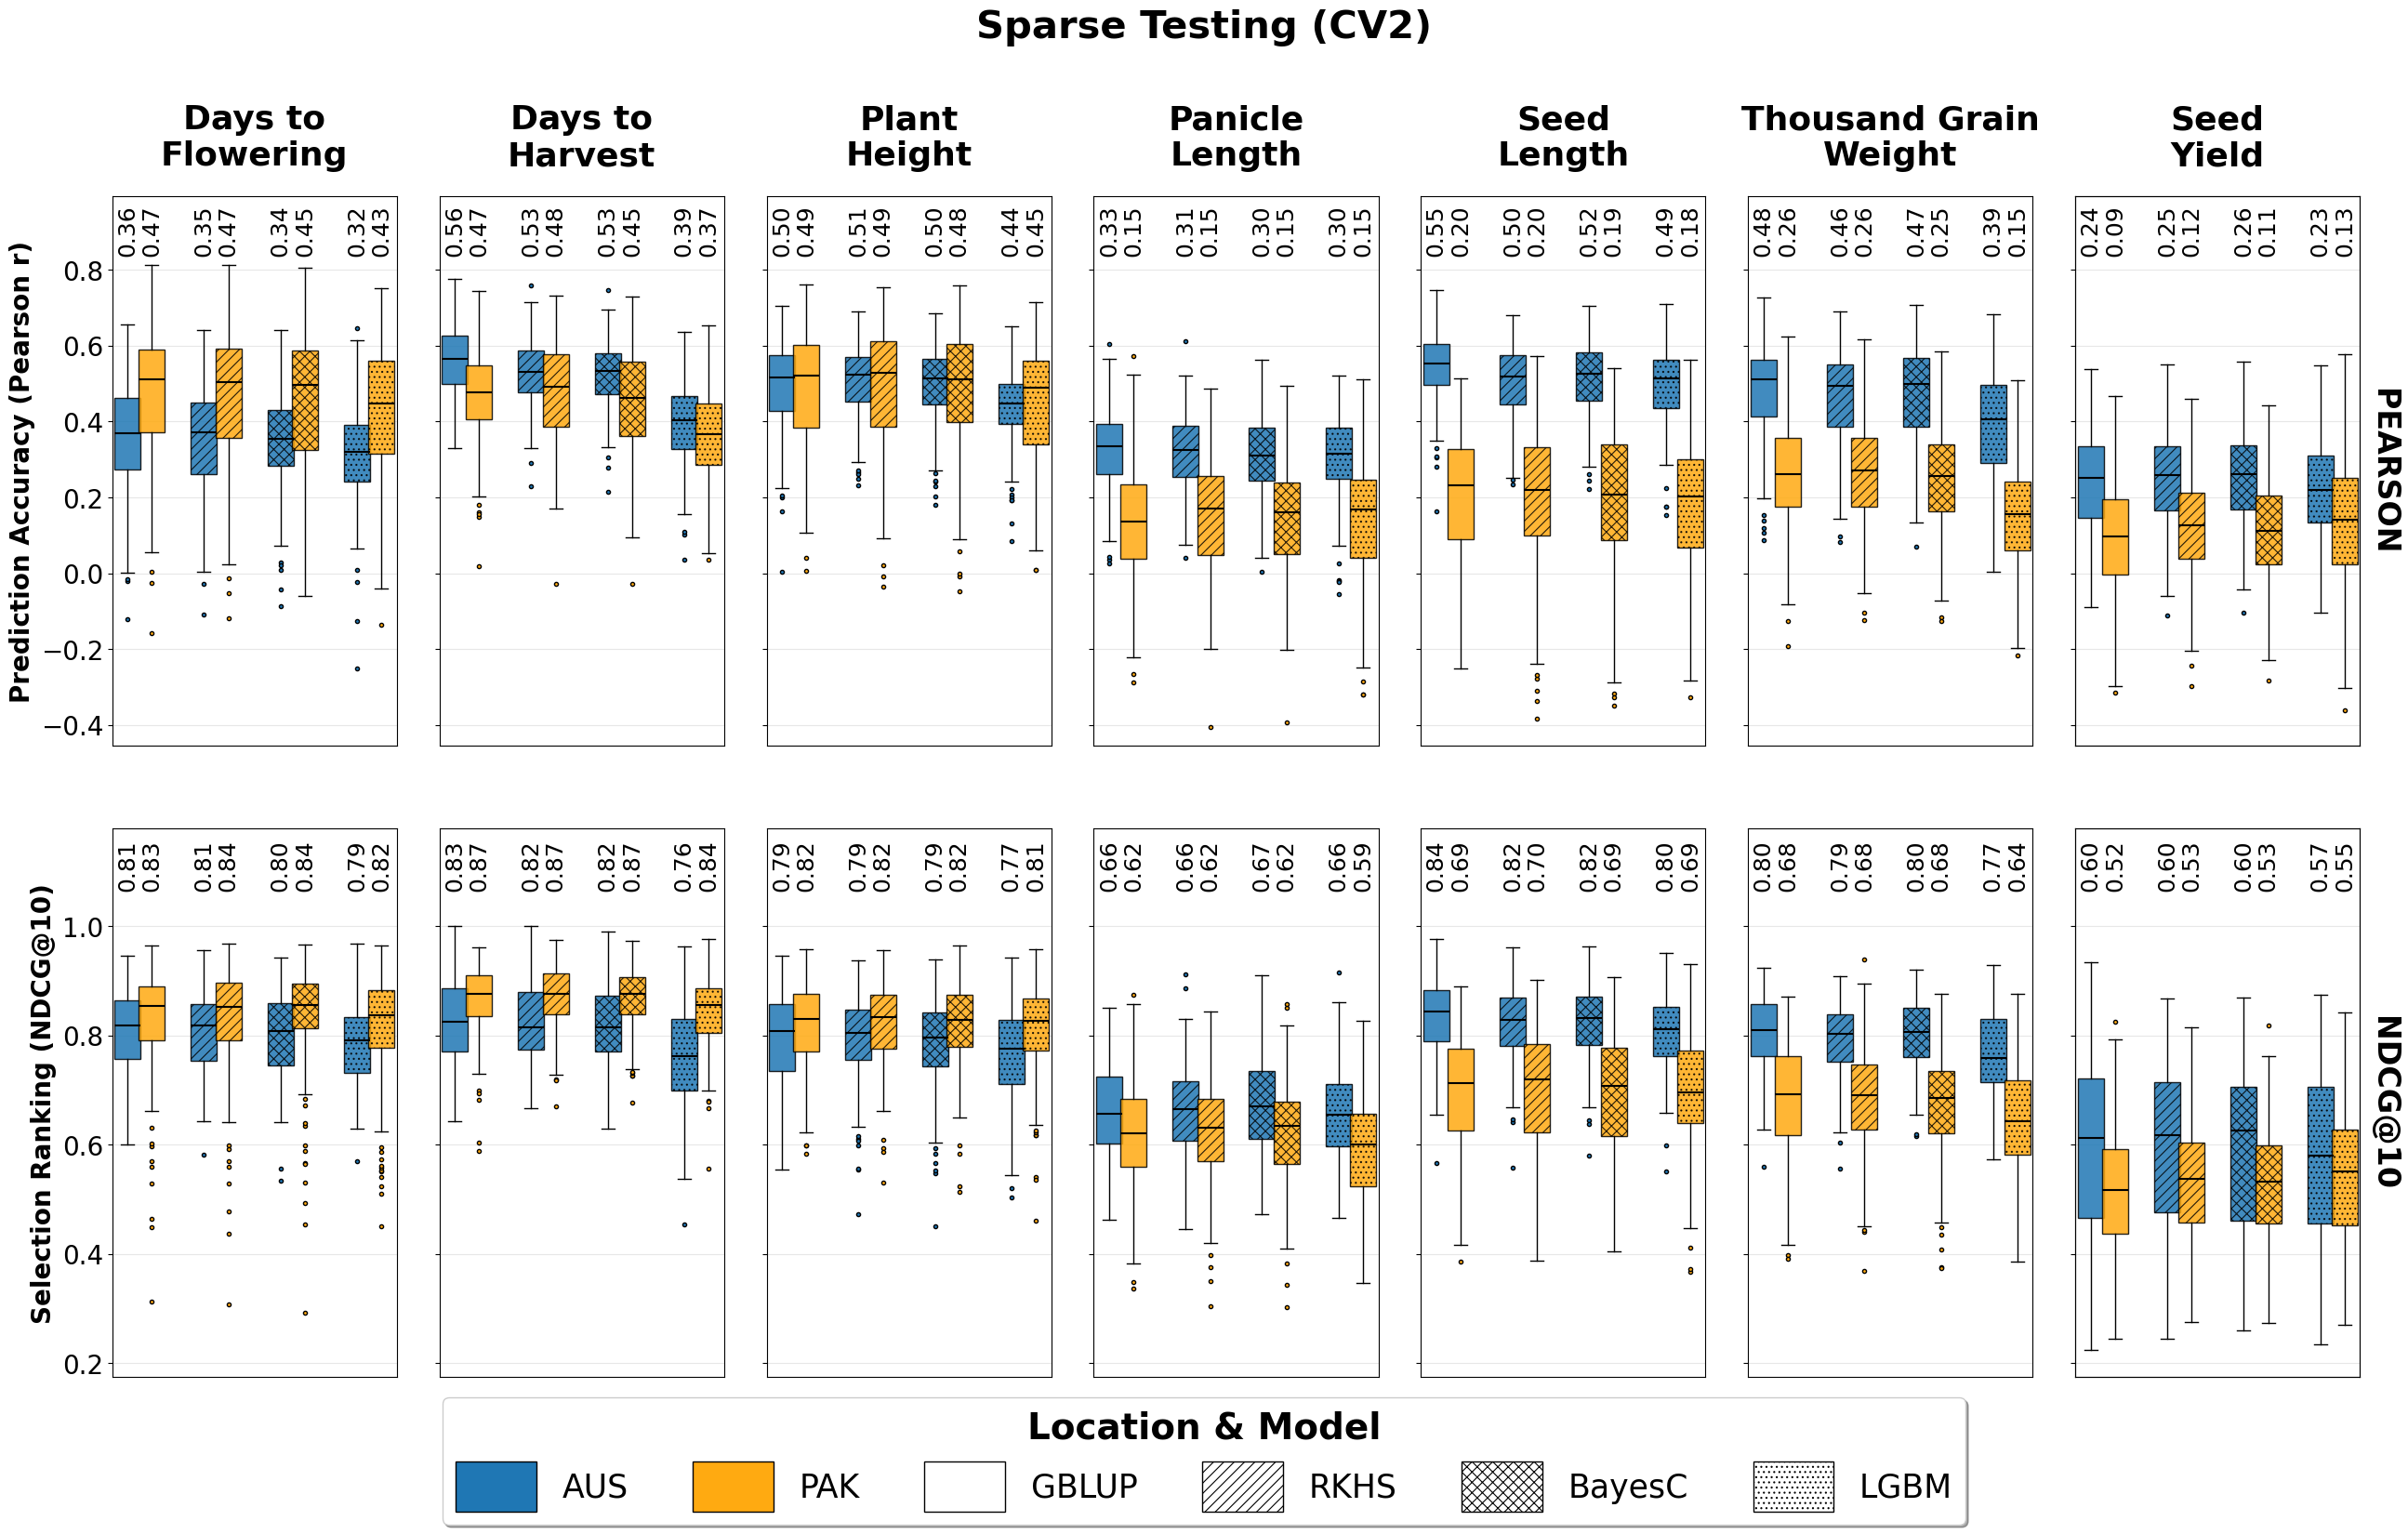

In [18]:
fig_cv2 = plot_results(gp_data['CV2'], 'CV2',
                       plot_type='box',
                       group_col='location',
                       group_colors=LOCATION_COLORS)
if fig_cv2:
    fig_cv2.savefig('Figure4.png',
                    dpi=300, bbox_inches='tight')
plt.show()

## Figure 5 — Leave-One-Location-Year-Out (CV0)

Forecasting performance for an unseen location-year. Each dot is one held-out location-year; horizontal bars show the mean per model × location.

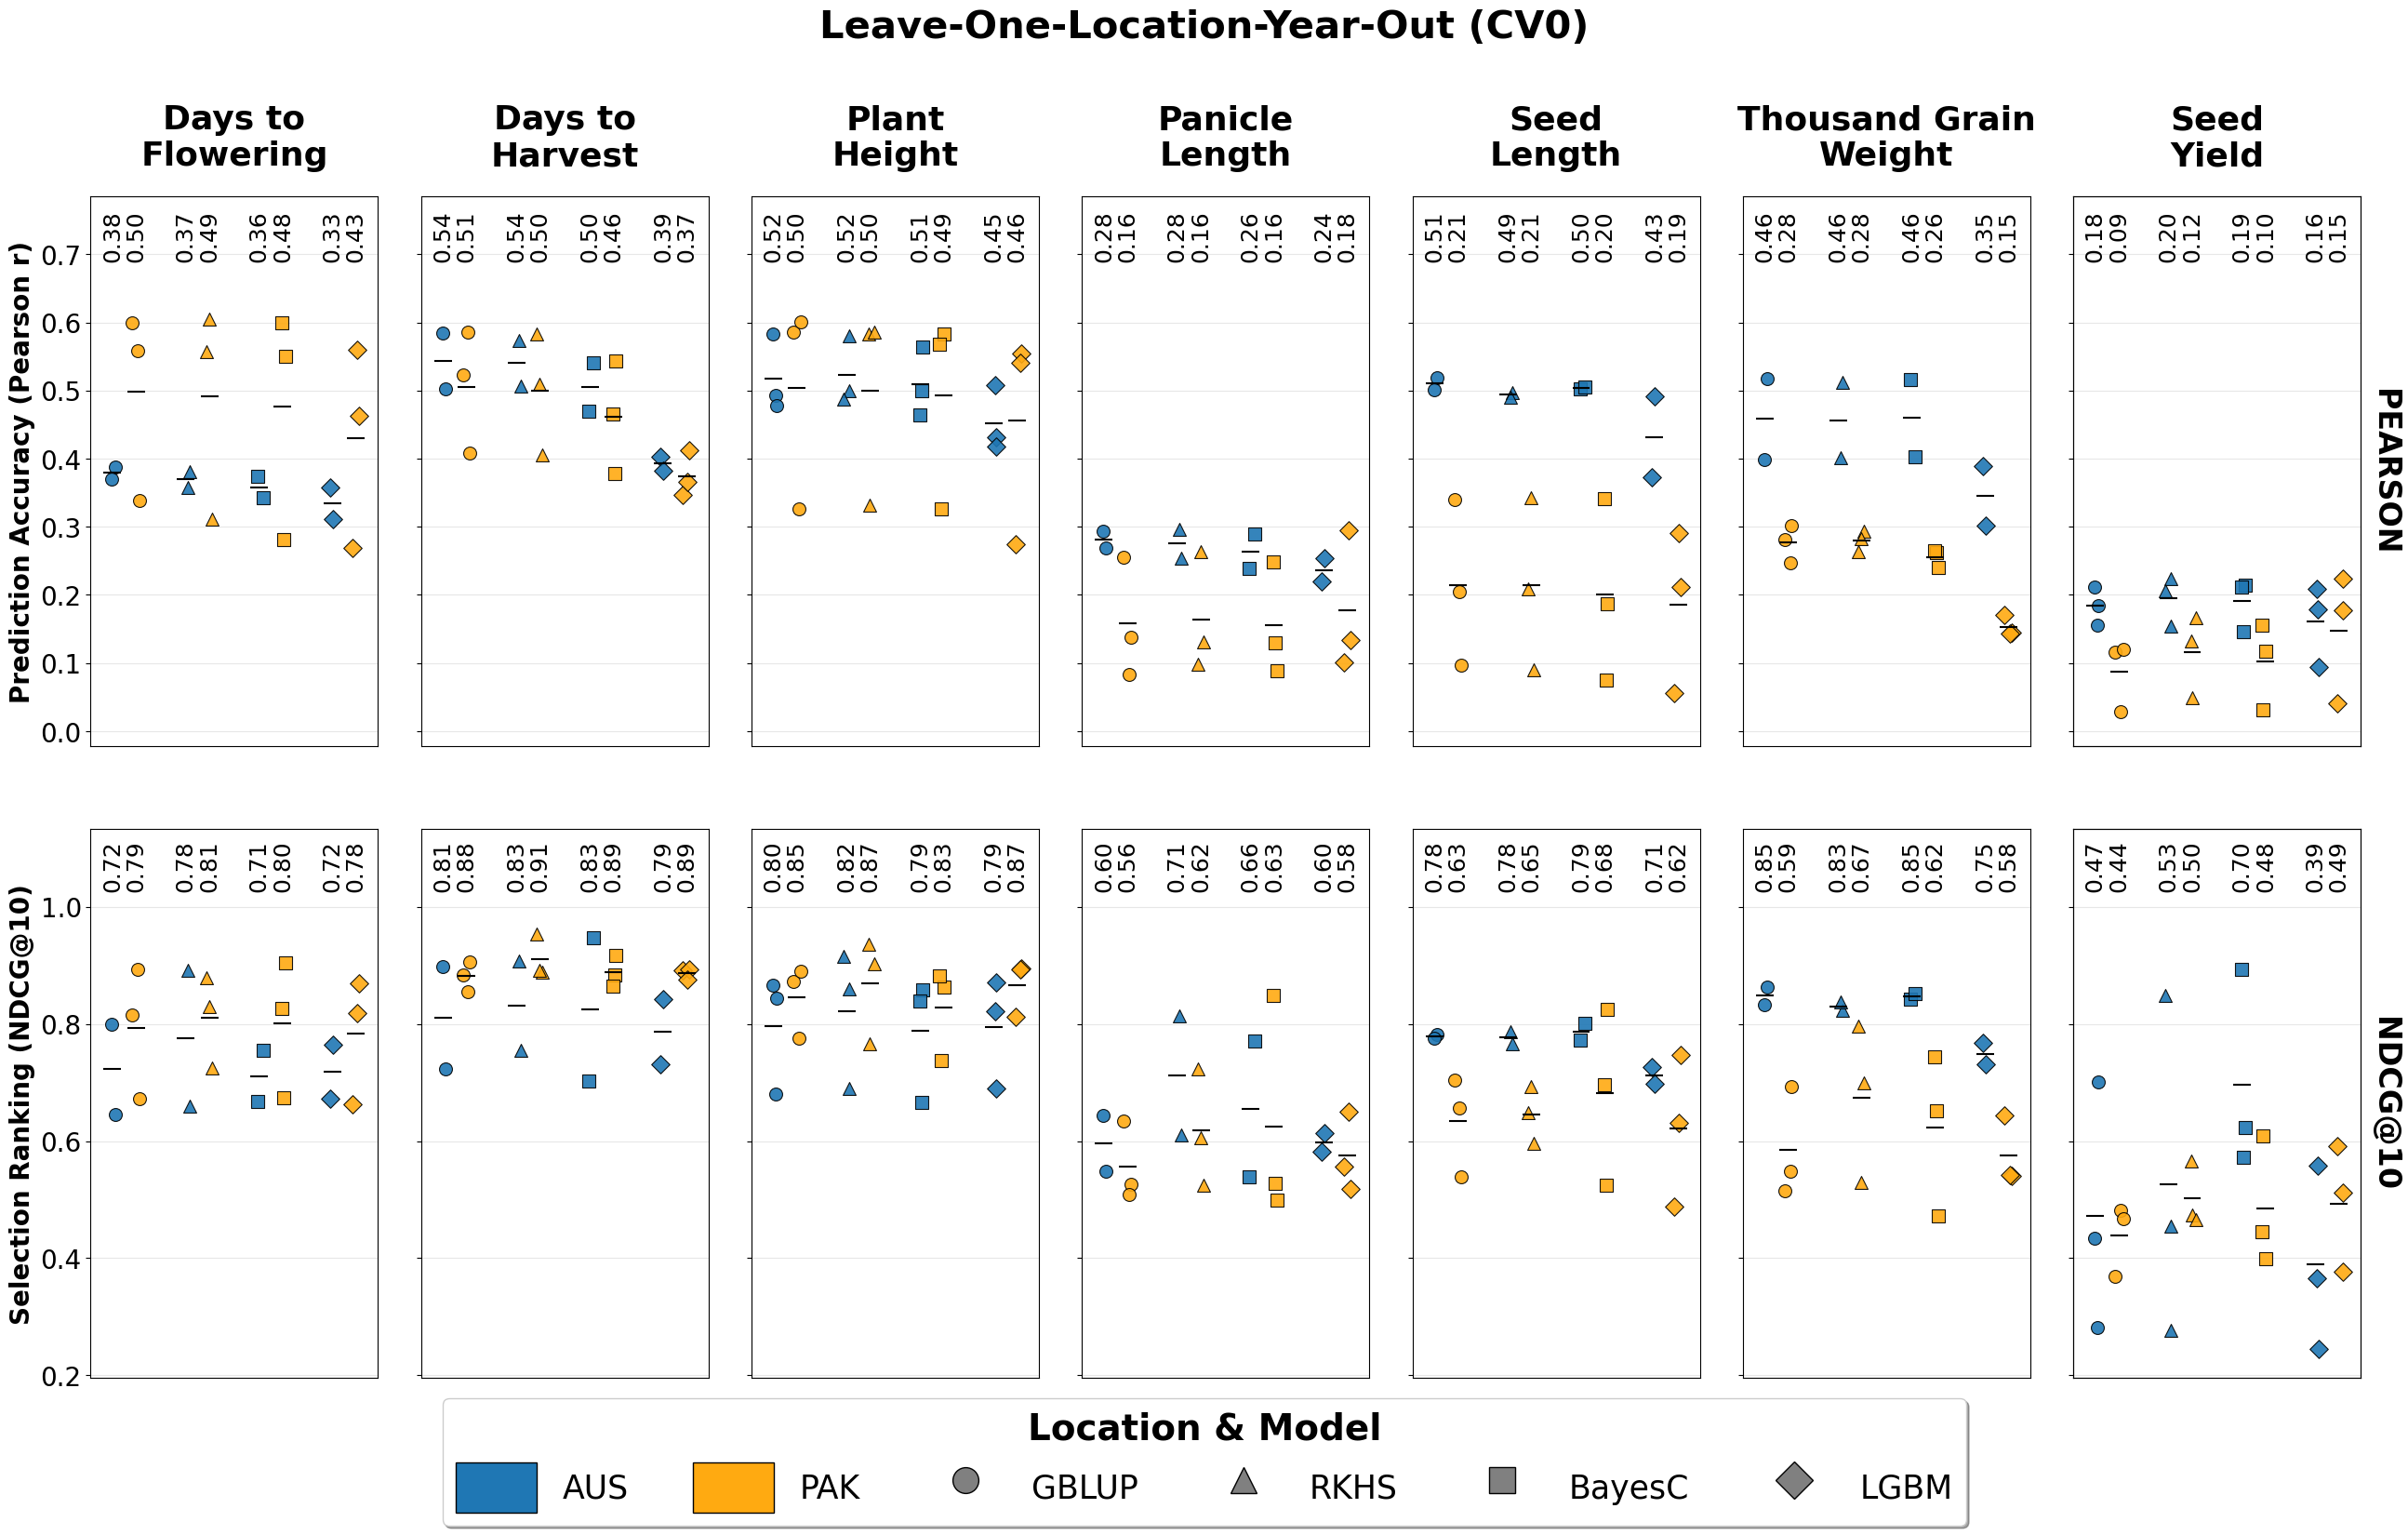

In [19]:
fig_cv0 = plot_results(gp_data['CV0'], 'CV0',
                       plot_type='dot',
                       group_col='location',
                       group_colors=LOCATION_COLORS)
if fig_cv0:
    fig_cv0.savefig('Figure5.png',
                    dpi=300, bbox_inches='tight')
plt.show()

## Figure 6 — Cross-Location

Train in one location, predict in the other (PAK→AUS and AUS→PAK). Each dot is one location-year; horizontal bars show the mean per model × direction.

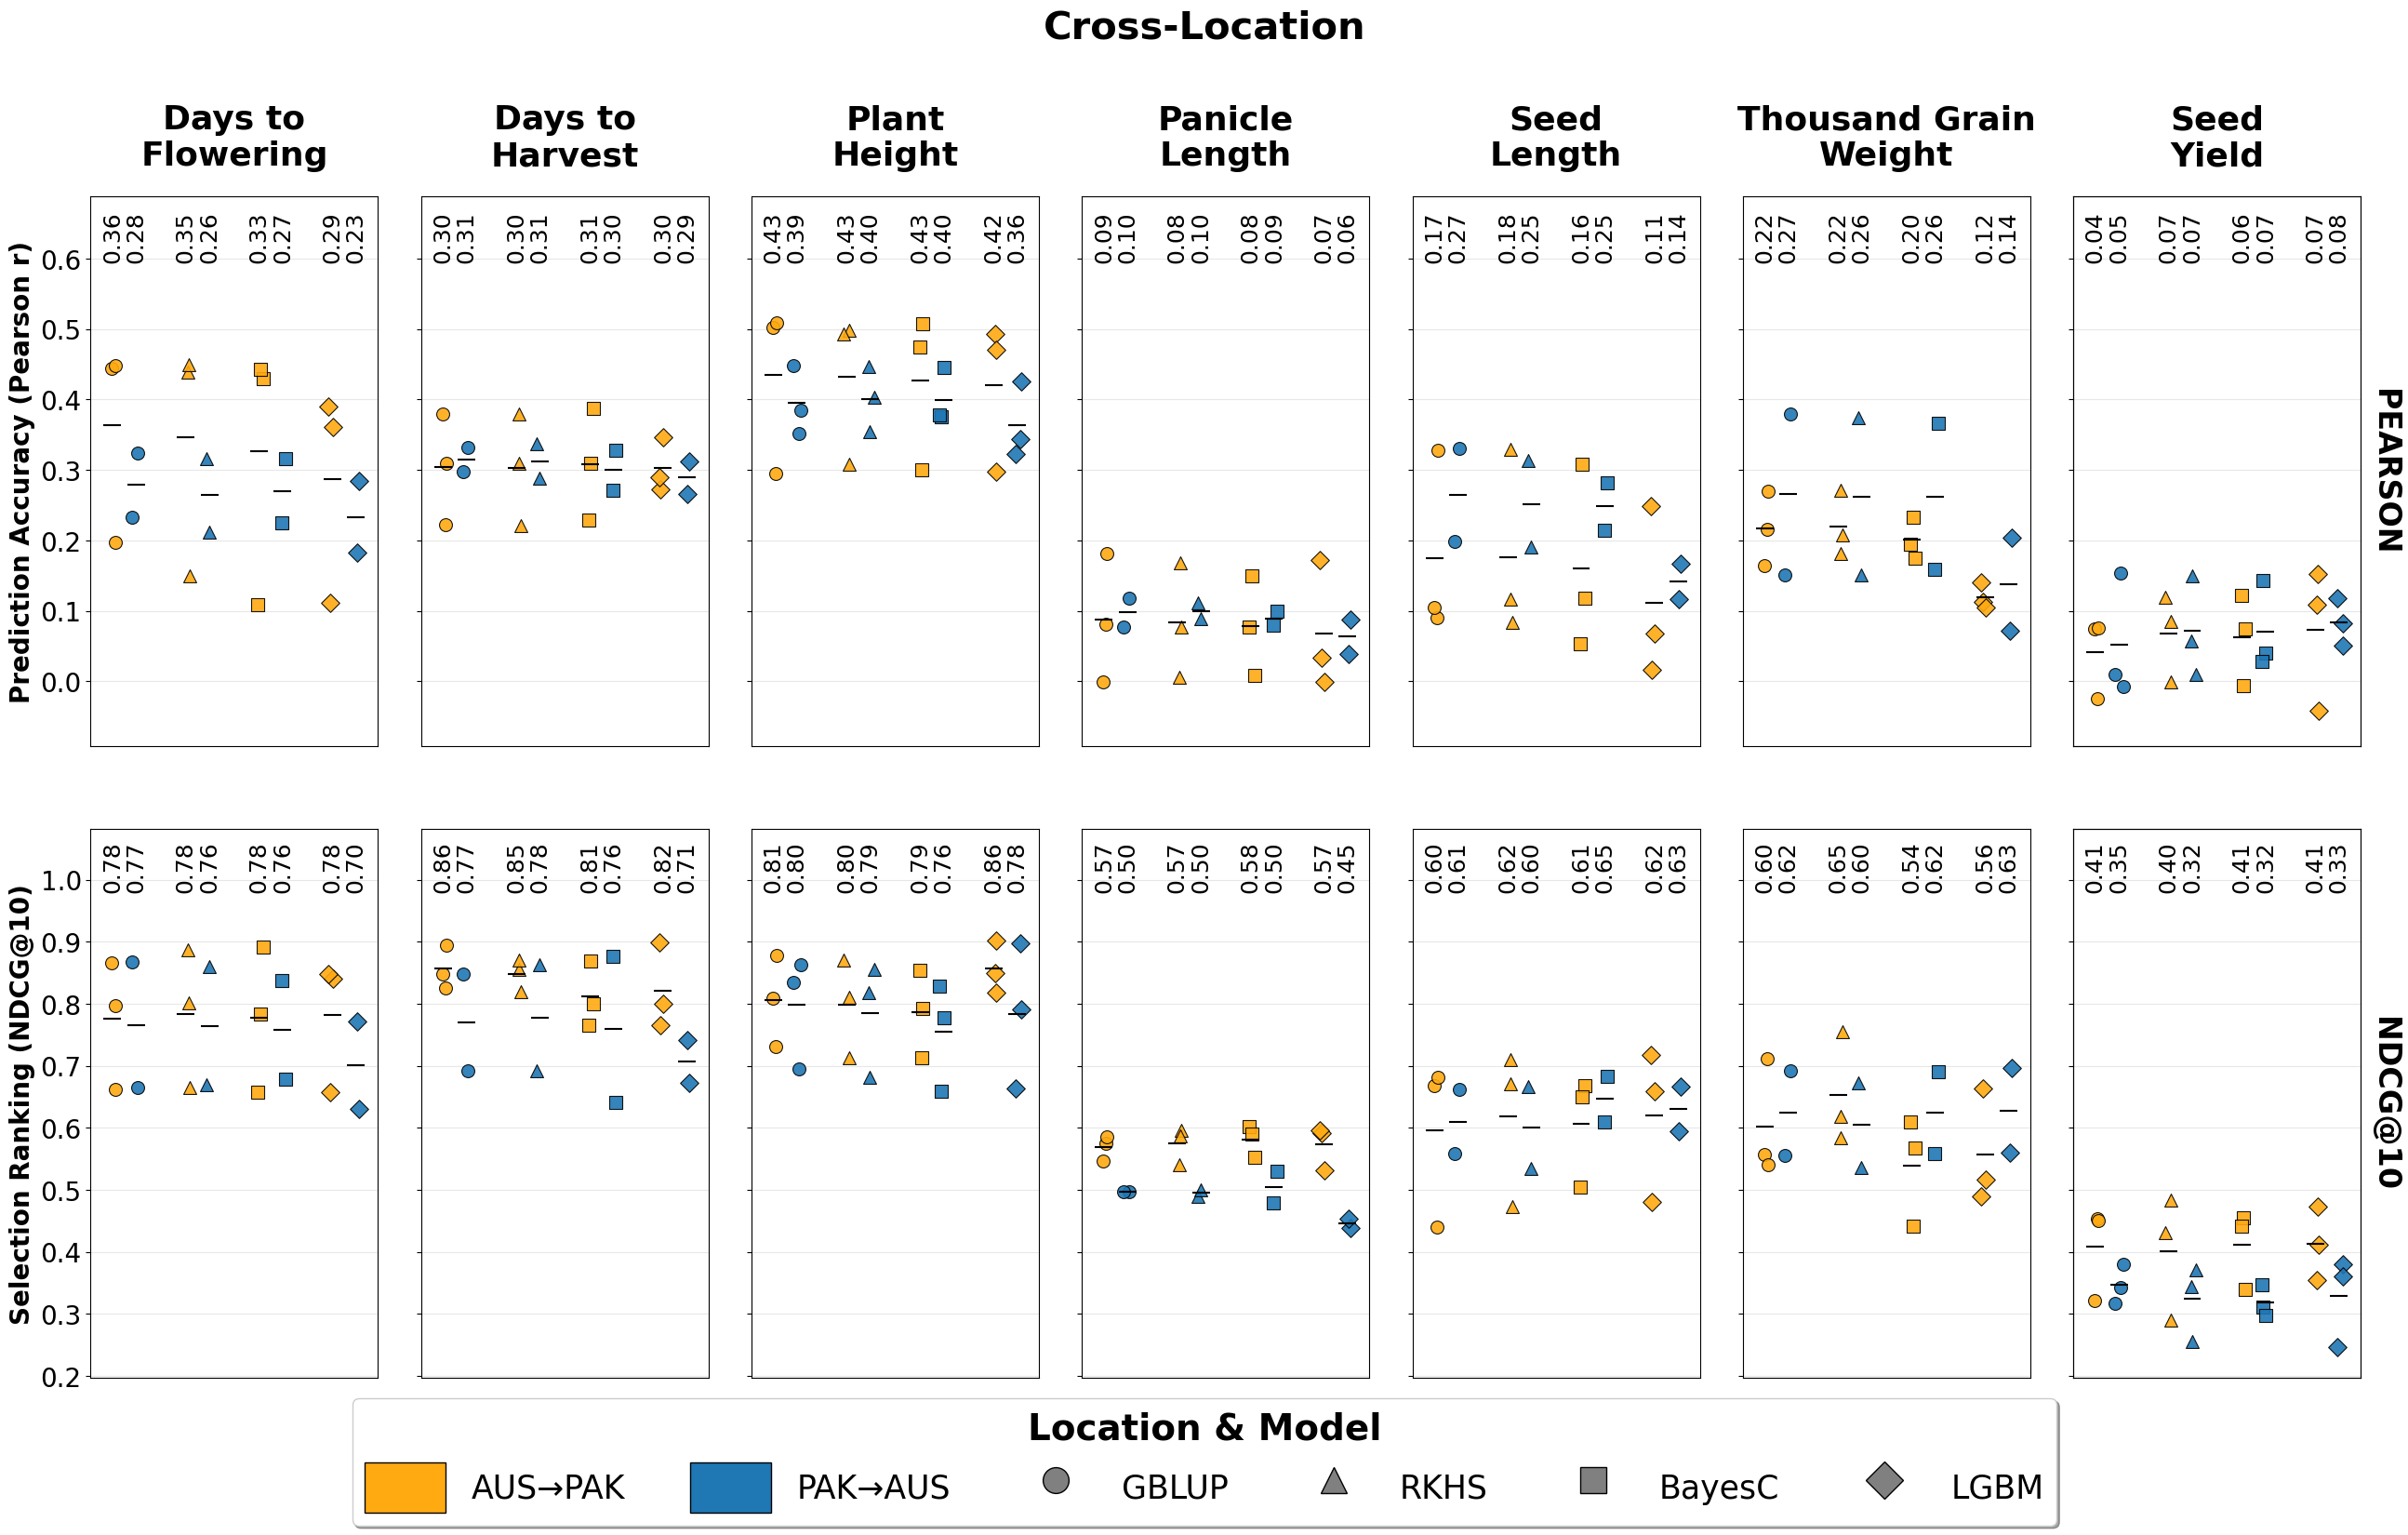

In [20]:
fig_cl = plot_results(gp_data['CrossLoc'], 'CrossLoc',
                      plot_type='dot',
                      group_col='direction',
                      group_colors=DIRECTION_COLORS)
if fig_cl:
    fig_cl.savefig('Figure6.png',
                   dpi=300, bbox_inches='tight')
plt.show()

## Figure 7 — GBLUP CV1: Global vs Per-Location Models

Compares two GBLUP fitting strategies under CV1: a single model trained jointly on both locations (**Global**) vs separate models fit independently within each location (**Per-Location**).

- **Global** rows are reused from `gp_data['CV1']` (same source as Figure 3).
- **Per-Location** rows live in `cv_results_cv1_per-location-model.csv`. 

In [ ]:
# ── One-shot prep: build merged per-location CSV ─────────────────────
# Run this cell once to produce cv_results_cv1_per-location-model.csv.
# If the merged file already exists,
# remains plottable from just the merged CSV alone (no per-trait folder).
import glob

PERLOC_MERGED_CSV = 'cv_results_cv1_per-location-model.csv'
PERLOC_SOURCE_DIR = 'results_mean_input/GBLUP_global_vs_per-location'

if os.path.exists(PERLOC_MERGED_CSV):
    print(f"Merged CSV already exists, skipping build: {PERLOC_MERGED_CSV}")
else:
    src_files = sorted(glob.glob(os.path.join(
        PERLOC_SOURCE_DIR, 'cv_results_*_GBLUP_CV1_per_location.csv')))
    if not src_files:
        raise FileNotFoundError(
            f"No per-trait CSVs found in {PERLOC_SOURCE_DIR}. "
            f"Provide {PERLOC_MERGED_CSV} directly to skip this build step."
        )
    merged = pd.concat([pd.read_csv(f) for f in src_files], ignore_index=True)
    merged.to_csv(PERLOC_MERGED_CSV, index=False)
    print(f"Wrote {PERLOC_MERGED_CSV}: {len(merged):,} rows "
          f"from {len(src_files)} per-trait files")

Wrote cv_results_cv1_per-location-model.csv: 2,775 rows from 7 per-trait files


Global GBLUP CV1:        2,775 rows
Per-location GBLUP CV1:  2,775 rows


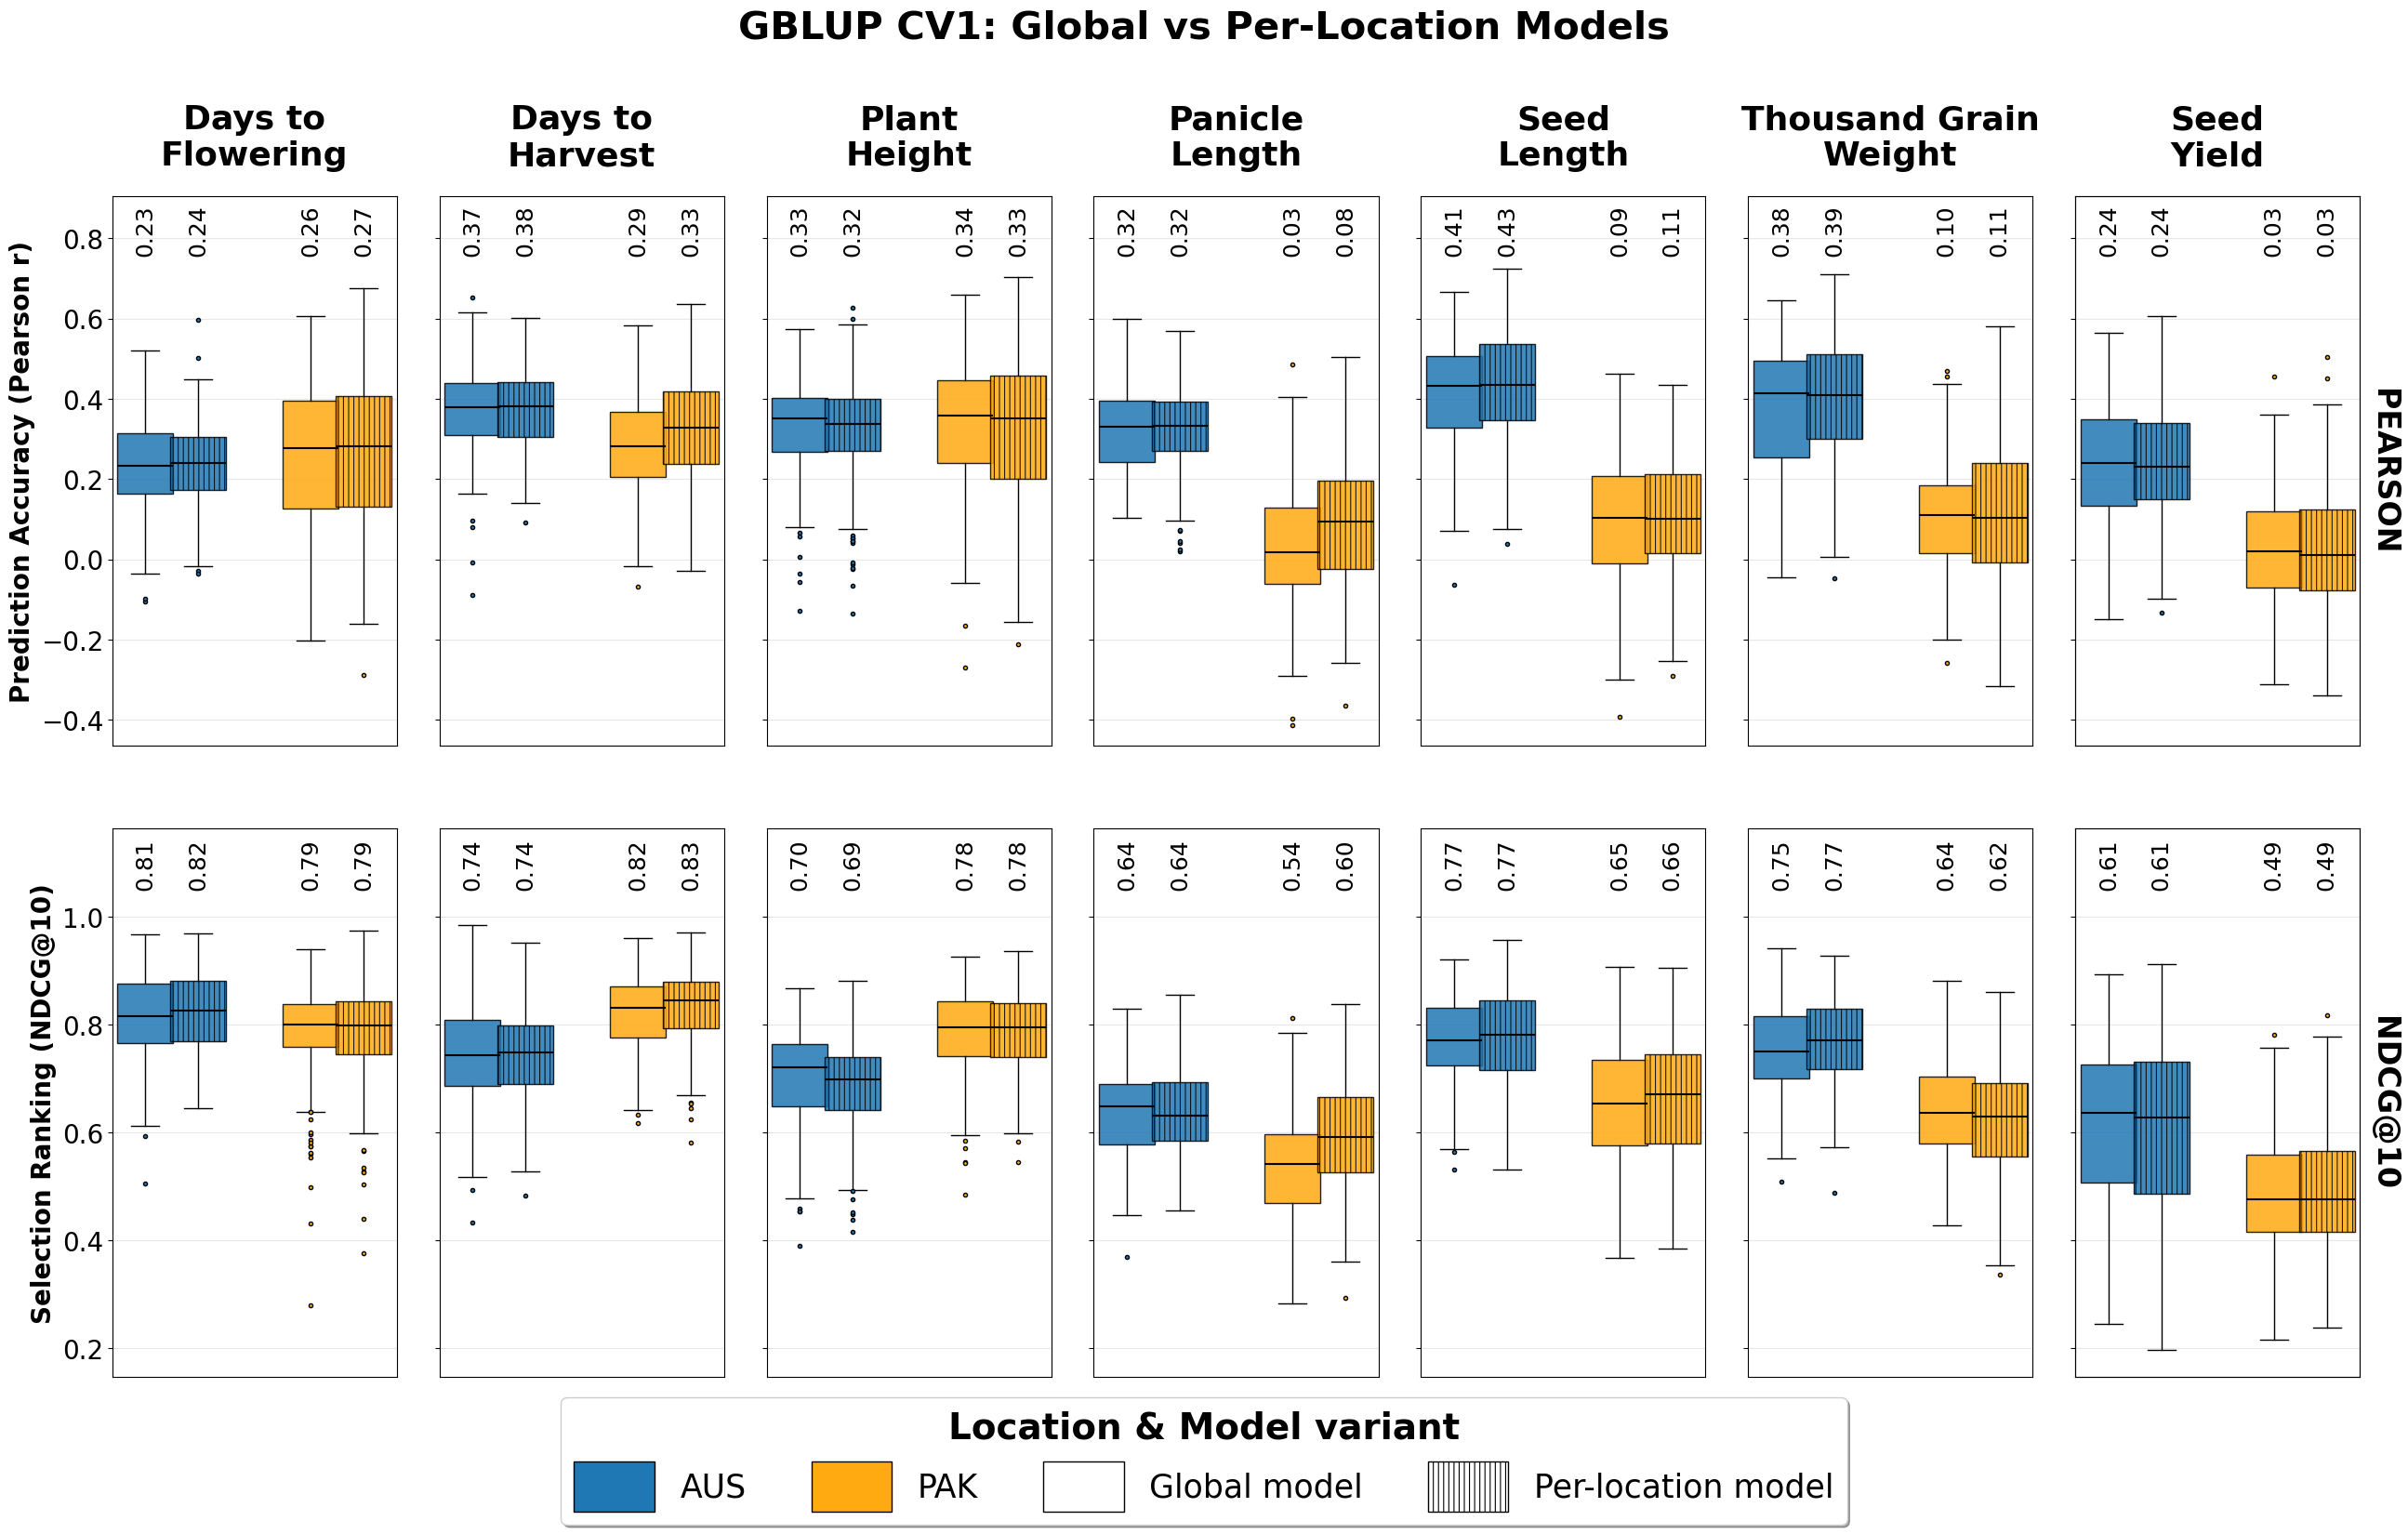

In [23]:
# ── Load + plot Figure 7 ──────────────────────────────────────────────
VARIANT_ORDER   = ['Global', 'PerLoc']
VARIANT_LABELS  = {'Global': 'Global model', 'PerLoc': 'Per-location model'}
VARIANT_HATCHES = {'Global': '', 'PerLoc': '|||'}
LOCATION_ORDER  = ['AUS', 'PAK']

# Global: reuse the GBLUP/CV1 subset already loaded into gp_data (Figure 3 source)
df_global = gp_data['CV1'].query("model == 'GBLUP'").copy()
df_global['variant'] = 'Global'
print(f"Global GBLUP CV1:        {len(df_global):,} rows")

# Per-location: load from the merged CSV produced by the prep cell above
df_perloc = pd.read_csv(PERLOC_MERGED_CSV)
for col in ['pearson', 'ndcg_at_10']:
    df_perloc[col] = pd.to_numeric(df_perloc[col], errors='coerce')
df_perloc['variant'] = 'PerLoc'
print(f"Per-location GBLUP CV1:  {len(df_perloc):,} rows")

keep_cols = ['trait', 'location', 'variant', 'pearson', 'ndcg_at_10']
combined_g_vs_p = pd.concat(
    [df_global[keep_cols], df_perloc[keep_cols]],
    ignore_index=True
)


def plot_global_vs_perloc(df, figsize=(26, 16)):
    if df.empty:
        print("No data to plot")
        return None
    melted = pd.melt(df, id_vars=['trait', 'location', 'variant'],
                     value_vars=METRICS, var_name='metric',
                     value_name='value').dropna(subset=['value'])

    traits   = [t for t in TRAIT_ORDER    if t in melted['trait'].unique()]
    locs     = [l for l in LOCATION_ORDER if l in melted['location'].unique()]
    variants = [v for v in VARIANT_ORDER  if v in melted['variant'].unique()]
    metrics  = [m for m in METRICS        if m in melted['metric'].unique()]

    nrows, ncols = len(metrics), len(traits)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey='row')
    plt.rcParams['hatch.linewidth'] = 0.8
    if nrows == 1: axes = axes.reshape(1, -1)
    if ncols == 1: axes = axes.reshape(-1, 1)

    n_var   = len(variants)
    loc_gap = n_var + 0.5
    loc_ctr = [i * loc_gap for i in range(len(locs))]

    for mi, metric in enumerate(metrics):
        vals_all = melted[melted['metric'] == metric]['value'].dropna()
        ymin = vals_all.min() - 0.05 if not vals_all.empty else 0
        ymax = vals_all.max() + 0.18 if not vals_all.empty else 1

        for ti, trait in enumerate(traits):
            ax = axes[mi, ti]
            subset = melted[(melted['metric'] == metric) &
                            (melted['trait'] == trait)]

            positions, data_list, colors, hatches_list = [], [], [], []

            for lidx, loc in enumerate(locs):
                ctr = loc_ctr[lidx]
                for vidx, variant in enumerate(variants):
                    pos  = ctr + (vidx - (n_var - 1) / 2) * 0.8
                    vals = subset[(subset['location'] == loc) &
                                  (subset['variant'] == variant)]['value'].values
                    if len(vals) > 0:
                        positions.append(pos)
                        data_list.append(vals)
                        colors.append(LOCATION_COLORS.get(loc, 'gray'))
                        hatches_list.append(VARIANT_HATCHES.get(variant, ''))

            if data_list:
                _draw_boxplot(ax, data_list, positions, colors, hatches_list)
                for pos, vals in zip(positions, data_list):
                    ax.text(pos, ymax - 0.02, f'{np.mean(vals):.2f}',
                            ha='center', va='top', fontsize=18,
                            fontweight='medium', rotation=90)

            ax.set_ylim(ymin, ymax)
            ax.set_xticks([])
            ax.grid(True, alpha=0.3, axis='y')
            ax.tick_params(axis='y', labelsize=20)

            if mi == 0:
                ax.set_title(TRAIT_LABELS.get(trait, trait),
                             fontsize=26, fontweight='bold', pad=24)
            if ti == ncols - 1:
                ax2 = ax.twinx()
                ax2.set_ylabel(METRIC_ROW_LABEL[metric], fontsize=24,
                               fontweight='bold', rotation=270, labelpad=30)
                ax2.set_yticks([])
            if ti == 0:
                ax.set_ylabel(METRIC_YAXIS[metric],
                              fontsize=20, fontweight='bold')

    loc_handles = [Patch(facecolor=LOCATION_COLORS[l], edgecolor='black',
                         label=l) for l in locs]
    variant_handles = [Patch(facecolor='white', edgecolor='black',
                             hatch=VARIANT_HATCHES[v],
                             label=VARIANT_LABELS[v]) for v in variants]
    all_handles = loc_handles + variant_handles

    leg = fig.legend(handles=all_handles, loc='lower center',
                     bbox_to_anchor=(0.5, -0.01),
                     ncol=len(all_handles), fontsize=25,
                     title='Location & Model variant', title_fontsize=28,
                     frameon=True, fancybox=True, shadow=True,
                     handleheight=2.0, handlelength=2.5)
    leg.get_title().set_fontweight('bold')

    fig.suptitle('GBLUP CV1: Global vs Per-Location Models',
                 fontsize=30, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10, wspace=0.15, hspace=0.15)
    return fig


fig_g_vs_p = plot_global_vs_perloc(combined_g_vs_p)
if fig_g_vs_p:
    fig_g_vs_p.savefig('Figure7.png',
                       dpi=300, bbox_inches='tight')
plt.show()